In [1]:
import numpy as np
import pandas as pd
import rasterio
import geopandas as gpd
import matplotlib.pyplot as plt
from pyproj import Transformer
import os
import gc
import warnings
warnings.filterwarnings('ignore')

In [2]:
# ---- CREATE OUTPUT FOLDER ----
result_folder = r"D:\\Important\Semester\Semester X\MTP\Shimla Result Paper based"
os.makedirs(result_folder, exist_ok=True)

# ---- PATHS ----
full_data_path = r"D:\\Important\Semester\Semester X\MTP\LSI\shimla_dataset.parquet"
reference_raster = r"D:\\Important\Semester\Semester X\MTP\Raw data\landslide_distance.tif"
shapefile_path = r"D:\Important\Semester\Semester X\MTP\DATA\shimla shp\shimla_boundary_utm.shp"

# ---- LOAD DATA ----
print("Loading full dataset...")
df = pd.read_parquet(full_data_path)
df["lulc"] = df["lulc"].astype(np.int8)
print(f"Full dataset: {df.shape[0]:,} pixels ({df.shape[0] * 100 / 1_000_000:.2f} sq.km)")

# ---- FEATURE COLUMNS ----
feature_cols = ["landslide_dist", "slope", "lulc", "elevation", "road_dist",
                "builtup_dist", "land_value", "water_dist", "lineament_dist",
                "lst", "railway_dist"]
class_labels = {1: "Very Low", 2: "Low", 3: "Moderate", 4: "High", 5: "Very High"}

# ---- RASTER METADATA ----
with rasterio.open(reference_raster) as src:
    raster_transform = src.transform
    raster_crs = src.crs
    raster_width = src.width
    raster_height = src.height

Loading full dataset...
Full dataset: 51,423,700 pixels (5142.37 sq.km)


# Step 1


STEP P1: EXTRACT HIGH SUITABILITY ZONES

Full district class distribution:
  Class              Pixels   Area (sq.km) Percentage
  --------------------------------------------------
  1 Very Low      1,060,985        106.10      2.06%
  2 Low          13,055,064       1305.51     25.39%
  3 Moderate     31,455,011       3145.50     61.17%
  4 High          5,826,106        582.61     11.33%
  5 Very High        26,534          2.65      0.05%

High suitability pixels extracted:
  Class 4 (High):       5,826,106 pixels
  Class 5 (Very High):     26,534 pixels
  Total:                5,852,640 pixels
  Area:                585.26 sq.km
  % of district:       11.38%

Feature characteristics of high suitability zones:
  Feature                  Mean        Min        Max
  --------------------------------------------------
  landslide_dist        2806.06     145.60   17721.50
  slope                   23.42       0.00      88.91
  lulc                     6.52       1.00      11.00
  elev

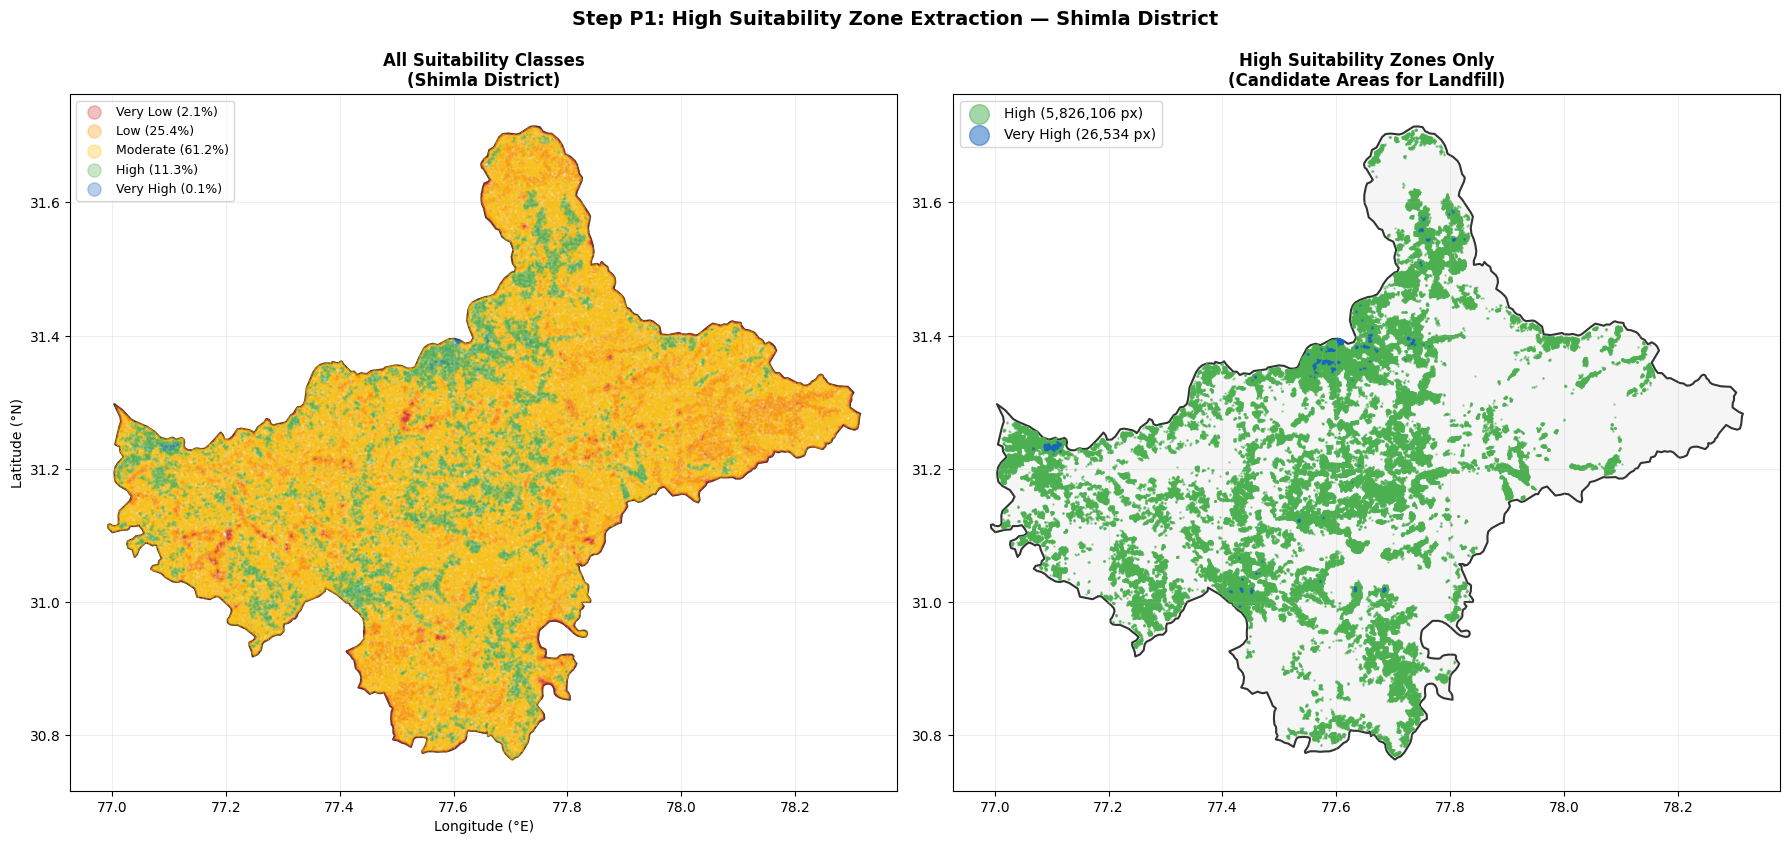


✓ Saved: P1_high_suitability_extraction.png


In [3]:
# ============================================================
# STEP P1: EXTRACT HIGH SUITABILITY ZONES
# ============================================================
print("\n" + "=" * 60)
print("STEP P1: EXTRACT HIGH SUITABILITY ZONES")
print("=" * 60)

# ---- FULL CLASS DISTRIBUTION ----
print("\nFull district class distribution:")
print(f"  {'Class':<12} {'Pixels':>12} {'Area (sq.km)':>14} {'Percentage':>10}")
print("  " + "-" * 50)
for cls in sorted(df["lsi_classified"].unique()):
    count = (df["lsi_classified"] == cls).sum()
    area = count * 100 / 1_000_000
    pct = (count / len(df)) * 100
    print(f"  {int(cls)} {class_labels[int(cls)]:<10} {count:>12,} {area:>13.2f} {pct:>9.2f}%")

# ---- EXTRACT CLASS 4 AND 5 ----
df_high = df[df["lsi_classified"].isin([4, 5])].copy().reset_index(drop=True)

print(f"\nHigh suitability pixels extracted:")
print(f"  Class 4 (High):      {(df_high['lsi_classified'] == 4).sum():>10,} pixels")
print(f"  Class 5 (Very High): {(df_high['lsi_classified'] == 5).sum():>10,} pixels")
print(f"  Total:               {len(df_high):>10,} pixels")
print(f"  Area:                {len(df_high) * 100 / 1_000_000:.2f} sq.km")
print(f"  % of district:       {len(df_high) / len(df) * 100:.2f}%")

# ---- FEATURE STATISTICS OF HIGH SUITABILITY PIXELS ----
print(f"\nFeature characteristics of high suitability zones:")
print(f"  {'Feature':<18} {'Mean':>10} {'Min':>10} {'Max':>10}")
print("  " + "-" * 50)
for col in feature_cols:
    print(f"  {col:<18} {df_high[col].mean():>10.2f} {df_high[col].min():>10.2f} {df_high[col].max():>10.2f}")

print(f"\n  LSI continuous: {df_high['lsi_continuous'].mean():.4f} mean, "
      f"{df_high['lsi_continuous'].min():.4f} min, {df_high['lsi_continuous'].max():.4f} max")

# ---- VISUALIZE HIGH SUITABILITY DISTRIBUTION ----
shimla = gpd.read_file(shapefile_path)
# Transformer
transformer_to_latlon = Transformer.from_crs("EPSG:32643", "EPSG:4326", always_xy=True)

# Convert shapefile to lat/long
shimla_latlon = shimla.to_crs("EPSG:4326")

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Left: All suitability classes
ax1 = axes[0]
# Use lat/lon shapefile
shimla_latlon.plot(ax=ax1, facecolor="#F5F5F5", edgecolor="#333333", linewidth=1.5)

# Plot all pixels as scatter (subsample for speed)
np.random.seed(42)
sample_all = df.sample(n=min(500_000, len(df)), random_state=42)

# Convert pixel coords to UTM for plotting
sample_x_utm = raster_transform.c + (sample_all["pixel_col"].values * raster_transform.a)
sample_y_utm = raster_transform.f + (sample_all["pixel_row"].values * raster_transform.e)
sample_x, sample_y = transformer_to_latlon.transform(sample_x_utm, sample_y_utm)

colors_map = {1: "#D32F2F", 2: "#FF9800", 3: "#FFC107", 4: "#4CAF50", 5: "#1565C0"}
for cls in [1, 2, 3, 4, 5]:
    mask = sample_all["lsi_classified"].values == cls
    if mask.sum() > 0:
        ax1.scatter(sample_x[mask], sample_y[mask], c=colors_map[cls], s=0.1, alpha=0.3,
                   label=f"{class_labels[cls]} ({(df['lsi_classified']==cls).sum()/len(df)*100:.1f}%)")

ax1.set_title("All Suitability Classes\n(Shimla District)", fontsize=12, fontweight="bold")
ax1.legend(loc="upper left", fontsize=9, markerscale=30)
ax1.set_xlabel("Easting (m)", fontsize=10)
ax1.set_ylabel("Northing (m)", fontsize=10)
ax1.grid(True, alpha=0.2)

# Right: High suitability only
ax2 = axes[1]
# Use lat/lon shapefile
shimla_latlon.plot(ax=ax2, facecolor="#F5F5F5", edgecolor="#333333", linewidth=1.5)

# Plot high suitability pixels
high_x_utm = raster_transform.c + (df_high["pixel_col"].values * raster_transform.a)
high_y_utm = raster_transform.f + (df_high["pixel_row"].values * raster_transform.e)
high_x, high_y = transformer_to_latlon.transform(high_x_utm, high_y_utm)

# Subsample if too many
if len(df_high) > 200_000:
    idx = np.random.choice(len(df_high), size=200_000, replace=False)
    high_x_plot = high_x[idx]
    high_y_plot = high_y[idx]
    high_cls_plot = df_high["lsi_classified"].values[idx]
else:
    high_x_plot = high_x
    high_y_plot = high_y
    high_cls_plot = df_high["lsi_classified"].values

for cls, color, label in [(4, "#4CAF50", "High"), (5, "#1565C0", "Very High")]:
    mask = high_cls_plot == cls
    if mask.sum() > 0:
        ax2.scatter(high_x_plot[mask], high_y_plot[mask], c=color, s=0.5, alpha=0.5,
                   label=f"{label} ({(df_high['lsi_classified']==cls).sum():,} px)")

ax2.set_title("High Suitability Zones Only\n(Candidate Areas for Landfill)", fontsize=12, fontweight="bold")
ax2.legend(loc="upper left", fontsize=10, markerscale=20)
ax1.set_xlabel("Longitude (°E)", fontsize=10)
ax1.set_ylabel("Latitude (°N)", fontsize=10)
ax2.grid(True, alpha=0.2)

plt.suptitle("Step P1: High Suitability Zone Extraction — Shimla District",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(result_folder, "P1_high_suitability_extraction.png"), dpi=300, bbox_inches='tight')
plt.show()
print(f"\n✓ Saved: P1_high_suitability_extraction.png")

# Step 2 & 3

STEP P2: CLUSTER CONNECTED PIXELS INTO CANDIDATE ZONES

Creating binary high-suitability raster...
  High suitability pixels placed: 5,852,640
Labeling connected components (8-connectivity)...
  Total clusters found: 33,374
Computing cluster sizes...

Cluster size distribution:
  Total clusters: 33,374
  Size Range                   Count  % of Clusters
  --------------------------------------------------
  1 pixel (0.01 ha)            5,831         17.47%
  2-10 pixels                 12,742         38.18%
  11-100 pixels (0.01-1 ha)   11,512         34.49%
  101-500 pixels (1-5 ha)      2,383          7.14%
  501-5000 pixels (5-50 ha)      755          2.26%
  5001-50000 (50-500 ha)         137          0.41%
  >50000 pixels (>500 ha)         14          0.04%

STEP P3: APPLY MINIMUM AREA THRESHOLD

Minimum area threshold: 10 hectares (1000 pixels)
  Clusters before filter: 33,374
  Clusters after filter:  549
  Clusters removed:       32,825

Surviving clusters (>= 10 ha):
  Cluster

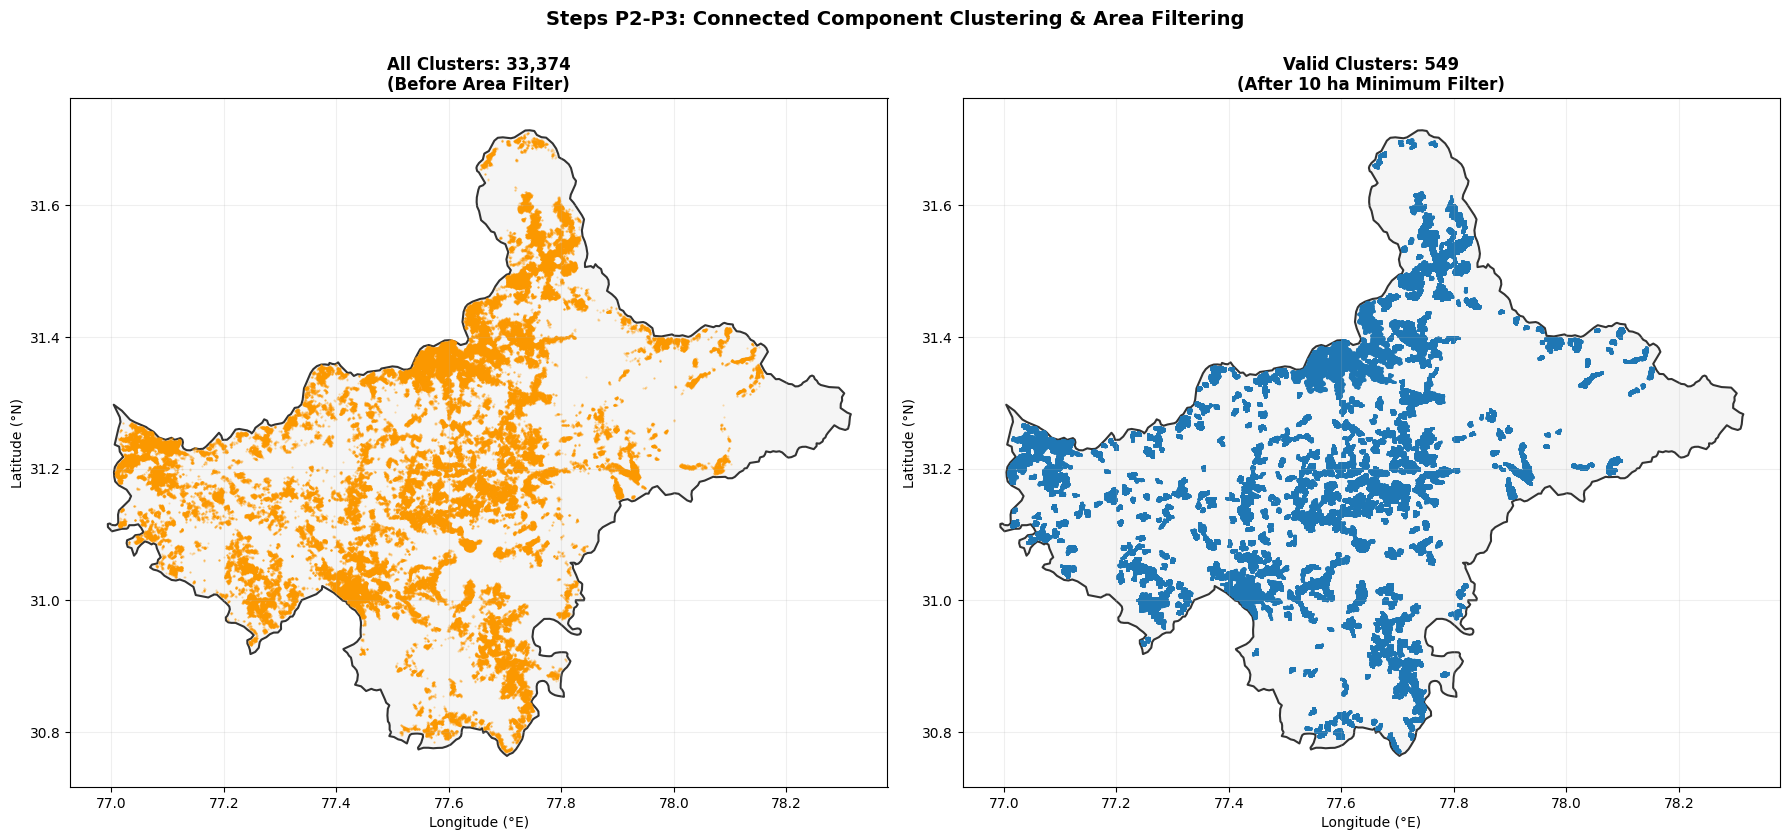


✓ Saved: P2_P3_clustering_and_filtering.png


12

In [4]:
from scipy import ndimage

# ============================================================
# STEP P2: CLUSTER CONNECTED HIGH SUITABILITY PIXELS
# ============================================================
print("=" * 60)
print("STEP P2: CLUSTER CONNECTED PIXELS INTO CANDIDATE ZONES")
print("=" * 60)

# ---- CREATE BINARY RASTER OF HIGH SUITABILITY ----
print("\nCreating binary high-suitability raster...")
high_raster = np.zeros((raster_height, raster_width), dtype=np.int8)
high_rows = df_high["pixel_row"].values
high_cols = df_high["pixel_col"].values
high_raster[high_rows, high_cols] = 1

print(f"  High suitability pixels placed: {high_raster.sum():,}")

# ---- LABEL CONNECTED COMPONENTS (8-connectivity) ----
print("Labeling connected components (8-connectivity)...")
structure = np.ones((3, 3), dtype=np.int8)  # 8-connectivity kernel
labeled_raster, num_clusters = ndimage.label(high_raster, structure=structure)

print(f"  Total clusters found: {num_clusters:,}")

# ---- COMPUTE CLUSTER SIZES ----
print("Computing cluster sizes...")
cluster_ids, cluster_sizes = np.unique(labeled_raster[labeled_raster > 0], return_counts=True)

# Convert to area
cluster_areas_sqm = cluster_sizes * 100  # each pixel = 100 sq.m
cluster_areas_ha = cluster_areas_sqm / 10_000  # hectares

print(f"\nCluster size distribution:")
print(f"  Total clusters: {len(cluster_ids):,}")
print(f"  {'Size Range':<25} {'Count':>8} {'% of Clusters':>14}")
print("  " + "-" * 50)

size_bins = [
    ("1 pixel (0.01 ha)", 1, 1),
    ("2-10 pixels", 2, 10),
    ("11-100 pixels (0.01-1 ha)", 11, 100),
    ("101-500 pixels (1-5 ha)", 101, 500),
    ("501-5000 pixels (5-50 ha)", 501, 5000),
    ("5001-50000 (50-500 ha)", 5001, 50000),
    (">50000 pixels (>500 ha)", 50001, float('inf'))
]

for label, low, high in size_bins:
    count = ((cluster_sizes >= low) & (cluster_sizes <= high)).sum()
    pct = (count / len(cluster_sizes)) * 100
    print(f"  {label:<25} {count:>8,} {pct:>13.2f}%")

# ============================================================
# STEP P3: APPLY MINIMUM AREA THRESHOLD
# ============================================================
print(f"\n{'=' * 60}")
print("STEP P3: APPLY MINIMUM AREA THRESHOLD")
print("=" * 60)

min_area_ha = 10  # minimum 5 hectares
min_pixels = int(min_area_ha * 10_000 / 100)  # 500 pixels

print(f"\nMinimum area threshold: {min_area_ha} hectares ({min_pixels} pixels)")

# Filter clusters by size
valid_mask = cluster_sizes >= min_pixels
valid_cluster_ids = cluster_ids[valid_mask]
valid_cluster_sizes = cluster_sizes[valid_mask]
valid_areas_ha = cluster_areas_ha[valid_mask]

print(f"  Clusters before filter: {len(cluster_ids):,}")
print(f"  Clusters after filter:  {len(valid_cluster_ids):,}")
print(f"  Clusters removed:       {len(cluster_ids) - len(valid_cluster_ids):,}")

print(f"\nSurviving clusters (>= {min_area_ha} ha):")
print(f"  {'Cluster ID':<12} {'Pixels':>10} {'Area (ha)':>12} {'Area (sq.km)':>14}")
print("  " + "-" * 50)

# Sort by size descending
sort_idx = np.argsort(valid_cluster_sizes)[::-1]
valid_cluster_ids = valid_cluster_ids[sort_idx]
valid_cluster_sizes = valid_cluster_sizes[sort_idx]
valid_areas_ha = valid_areas_ha[sort_idx]

for cid, size, area in zip(valid_cluster_ids, valid_cluster_sizes, valid_areas_ha):
    print(f"  {cid:<12} {size:>10,} {area:>12.2f} {area/100:>14.4f}")

total_valid_area = valid_areas_ha.sum()
print(f"\n  Total valid area: {total_valid_area:.2f} ha ({total_valid_area/100:.2f} sq.km)")
print(f"  % of district: {total_valid_area * 10_000 / (5143 * 1_000_000) * 100:.2f}%")

# ---- ASSIGN CLUSTER IDS TO DATAFRAME ----
print("\nAssigning cluster IDs to high-suitability pixels...")
df_high["cluster_id"] = labeled_raster[high_rows, high_cols]
df_high["cluster_valid"] = df_high["cluster_id"].isin(valid_cluster_ids)

print(f"  Pixels in valid clusters: {df_high['cluster_valid'].sum():,}")
print(f"  Pixels in removed clusters: {(~df_high['cluster_valid']).sum():,}")

# ---- VISUALIZE ----
print("\nGenerating cluster visualization...")
shimla_latlon = shimla.to_crs("EPSG:4326")
transformer_to_latlon = Transformer.from_crs("EPSG:32643", "EPSG:4326", always_xy=True)

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Left: All clusters (before filtering)
ax1 = axes[0]
shimla_latlon.plot(ax=ax1, facecolor="#F5F5F5", edgecolor="#333333", linewidth=1.5)

high_x_utm = raster_transform.c + (high_cols * raster_transform.a)
high_y_utm = raster_transform.f + (high_rows * raster_transform.e)
high_lon, high_lat = transformer_to_latlon.transform(high_x_utm, high_y_utm)

# Subsample for plotting
np.random.seed(42)
if len(high_lon) > 200_000:
    idx = np.random.choice(len(high_lon), size=200_000, replace=False)
else:
    idx = np.arange(len(high_lon))

ax1.scatter(high_lon[idx], high_lat[idx], c="#FF9800", s=0.3, alpha=0.3)
ax1.set_title(f"All Clusters: {num_clusters:,}\n(Before Area Filter)", fontsize=12, fontweight="bold")
ax1.set_xlabel("Longitude (°E)", fontsize=10)
ax1.set_ylabel("Latitude (°N)", fontsize=10)
ax1.grid(True, alpha=0.2)

# Right: Valid clusters only (after filtering)
ax2 = axes[1]
shimla_latlon.plot(ax=ax2, facecolor="#F5F5F5", edgecolor="#333333", linewidth=1.5)

# Plot each valid cluster with different color
colors = plt.cm.tab20(np.linspace(0, 1, max(len(valid_cluster_ids), 1)))
for i, cid in enumerate(valid_cluster_ids):
    cluster_mask = df_high["cluster_id"].values == cid
    c_rows = high_rows[cluster_mask]
    c_cols = high_cols[cluster_mask]
    c_x_utm = raster_transform.c + (c_cols * raster_transform.a)
    c_y_utm = raster_transform.f + (c_rows * raster_transform.e)
    c_lon, c_lat = transformer_to_latlon.transform(c_x_utm, c_y_utm)
    
    # Subsample large clusters
    if len(c_lon) > 50_000:
        sub_idx = np.random.choice(len(c_lon), size=50_000, replace=False)
        c_lon, c_lat = c_lon[sub_idx], c_lat[sub_idx]
    
    ax2.scatter(c_lon, c_lat, c=[colors[i % 20]], s=0.5, alpha=0.5,
               label=f"C{cid} ({valid_areas_ha[i]:.1f} ha)")

ax2.set_title(f"Valid Clusters: {len(valid_cluster_ids)}\n(After {min_area_ha} ha Minimum Filter)",
              fontsize=12, fontweight="bold")
ax2.set_xlabel("Longitude (°E)", fontsize=10)
ax2.set_ylabel("Latitude (°N)", fontsize=10)
ax2.grid(True, alpha=0.2)

# Only show legend if reasonable number of clusters
if len(valid_cluster_ids) <= 20:
    ax2.legend(loc="upper left", fontsize=8, markerscale=20)

plt.suptitle("Steps P2-P3: Connected Component Clustering & Area Filtering",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(result_folder, "P2_P3_clustering_and_filtering.png"), dpi=300, bbox_inches='tight')
plt.show()
print(f"\n✓ Saved: P2_P3_clustering_and_filtering.png")

# ---- FREE MEMORY ----
del high_raster, labeled_raster
gc.collect()

# Step 4

STEP P4: ENVIRONMENTAL CONSTRAINT FILTERING
Distance to Shimla MC computed: min=1082 m, max=98227 m

Constraints applied:
  Distance from water > 200m [CPHEEO 2016]
  Distance from built-up > 500m [CPHEEO 2016]
  Distance from roads < 2000m [Accessibility requirement]
  Slope < 25 degrees [Construction feasibility]
  Distance from landslides > 500m [Safety requirement]
  Distance from lineaments > 150m [Groundwater protection]
  Elevation < 2400m [Paper Table 3 — Very Low suitability above 2400m]
  Distance from Shimla MC < 30km [Practical haulage cap to replace Bharial landfill]

Pixels before constraint filtering: 4,658,952
  Distance from water > 200m: 24,940 pixels removed (0.54%)
  Distance from built-up > 500m: 3,024,550 pixels removed (64.92%)
  Distance from roads < 2000m: 54,402 pixels removed (1.17%)
  Slope < 25 degrees: 1,928,528 pixels removed (41.39%)
  Distance from landslides > 500m: 14,720 pixels removed (0.32%)
  Distance from lineaments > 150m: 203,482 pixels removed

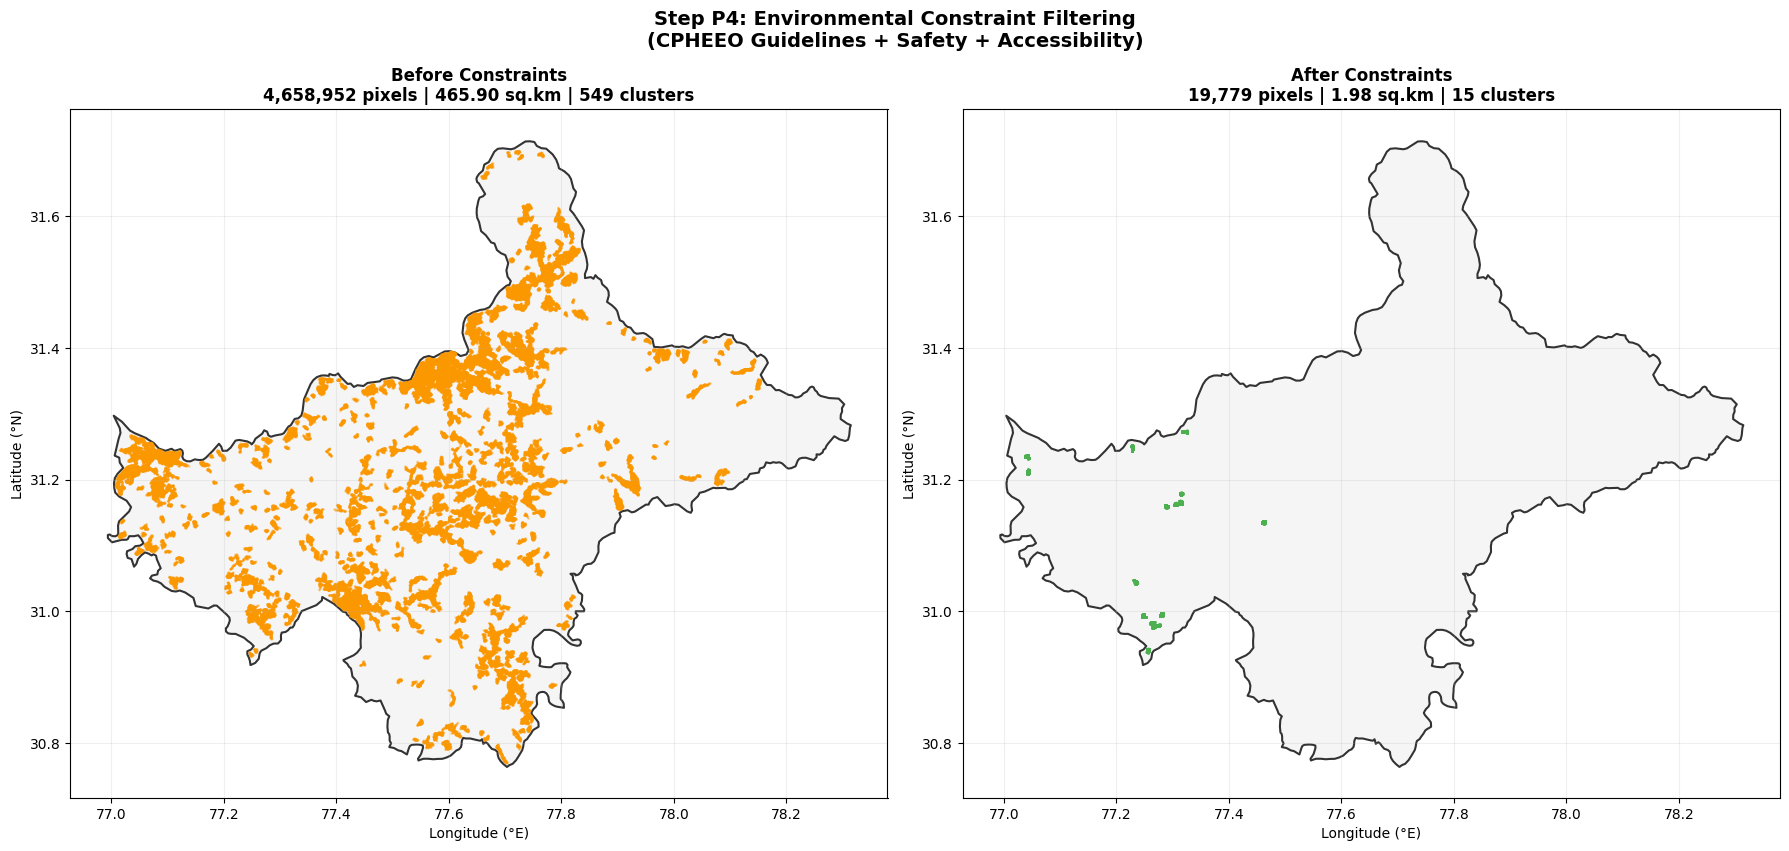


✓ Saved: P4_constraint_filtering.png


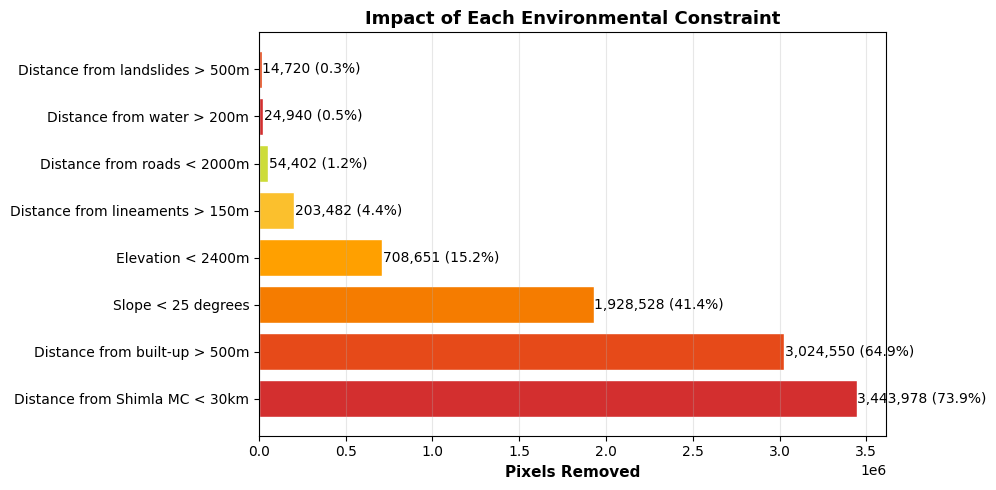

✓ Saved: P4_constraint_impact.png

REASONING AND METHODOLOGY NOTES

1. WHY THESE SPECIFIC CONSTRAINTS?
   - Water distance (>200m): CPHEEO 2016 mandates minimum 200m from ponds,
     lakes, and water bodies to prevent leachate contamination of surface
     water and aquatic ecosystems.
   - Built-up distance (>500m): CPHEEO 2016 requires all landfill facilities
     to maintain 500m from habitation to minimize health hazards (odor,
     disease vectors, noise) to nearby populations.
   - Road distance (<2000m): No landfill can operate without road access for
     waste transport vehicles. 2000m is the practical maximum distance in
     hilly terrain where building new access roads is extremely expensive.
     This threshold balances accessibility against the cost of road construction.
   - Slope (<25 degrees): Slopes above 25 degrees pose severe construction
     challenges in hilly terrain — heavy machinery cannot operate safely,
     waste containment is compromised, and landslide ri

In [5]:
# ============================================================
# STEP P4: APPLY ENVIRONMENTAL CONSTRAINT FILTERS
# ============================================================
print("=" * 60)
print("STEP P4: ENVIRONMENTAL CONSTRAINT FILTERING")
print("=" * 60)

# ---- COMPUTE DISTANCE FROM SHIMLA MC (for Analysis B haulage cap) ----
# Shimla MC centroid: 77.1734 E, 31.1048 N (paper's reference point)
from pyproj import Transformer
_t_to_utm = Transformer.from_crs("EPSG:4326", "EPSG:32643", always_xy=True)
shimla_mc_x, shimla_mc_y = _t_to_utm.transform(77.1734, 31.1048)

# Pixel UTM coordinates for every row in df_high (cluster_valid pixels)
_px_x = raster_transform.c + (df_high["pixel_col"].values * raster_transform.a)
_px_y = raster_transform.f + (df_high["pixel_row"].values * raster_transform.e)
df_high["dist_shimla_mc"] = np.sqrt(
    (_px_x - shimla_mc_x) ** 2 + (_px_y - shimla_mc_y) ** 2
)
print(f"Distance to Shimla MC computed: "
      f"min={df_high['dist_shimla_mc'].min():.0f} m, "
      f"max={df_high['dist_shimla_mc'].max():.0f} m")


# ---- DEFINE CONSTRAINTS (based on CPHEEO guidelines + practical criteria) ----
constraints = {
    "water_dist":      {"min": 200,  "label": "Distance from water > 200m",     "source": "CPHEEO 2016"},
    "builtup_dist":    {"min": 500,  "label": "Distance from built-up > 500m",  "source": "CPHEEO 2016"},
    "road_dist":       {"max": 2000, "label": "Distance from roads < 2000m",    "source": "Accessibility requirement"},
    "slope":           {"max": 25,   "label": "Slope < 25 degrees",             "source": "Construction feasibility"},
    "landslide_dist":  {"min": 500,  "label": "Distance from landslides > 500m","source": "Safety requirement"},
    "lineament_dist":  {"min": 150,  "label": "Distance from lineaments > 150m","source": "Groundwater protection"},
    "elevation":       {"max": 2400, "label": "Elevation < 2400m",              "source": "Paper Table 3 — Very Low suitability above 2400m"},
    "dist_shimla_mc":  {"max": 30000,"label": "Distance from Shimla MC < 30km", "source": "Practical haulage cap to replace Bharial landfill"},
}

print("\nConstraints applied:")
for feat, params in constraints.items():
    if "min" in params:
        print(f"  {params['label']} [{params['source']}]")
    else:
        print(f"  {params['label']} [{params['source']}]")

# ---- FILTER ONLY VALID CLUSTER PIXELS ----
df_valid = df_high[df_high["cluster_valid"]].copy()
print(f"\nPixels before constraint filtering: {len(df_valid):,}")

# ---- APPLY EACH CONSTRAINT ----
constraint_results = {}
surviving_mask = np.ones(len(df_valid), dtype=bool)

for feat, params in constraints.items():
    if "min" in params:
        mask = df_valid[feat].values >= params["min"]
    else:
        mask = df_valid[feat].values <= params["max"]
    
    removed = (~mask).sum()
    pct_removed = (removed / len(df_valid)) * 100
    constraint_results[params["label"]] = {
        "removed": removed,
        "pct": pct_removed
    }
    surviving_mask &= mask
    print(f"  {params['label']}: {removed:,} pixels removed ({pct_removed:.2f}%)")

pixels_after = surviving_mask.sum()
total_removed = len(df_valid) - pixels_after
print(f"\n  Total pixels after ALL constraints: {pixels_after:,}")
print(f"  Total removed: {total_removed:,} ({total_removed/len(df_valid)*100:.2f}%)")

# ---- APPLY CONSTRAINT MASK ----
df_constrained = df_valid[surviving_mask].copy().reset_index(drop=True)

print(f"\n  Area after constraints: {len(df_constrained) * 100 / 1_000_000:.2f} sq.km")
print(f"  Area before constraints: {len(df_valid) * 100 / 1_000_000:.2f} sq.km")
print(f"  Area reduction: {(1 - len(df_constrained)/len(df_valid))*100:.2f}%")

# ============================================================
# RE-CLUSTER AFTER CONSTRAINT FILTERING
# ============================================================
print(f"\n{'=' * 60}")
print("RE-CLUSTERING AFTER CONSTRAINT REMOVAL")
print("=" * 60)

# Rebuild binary raster with only constrained pixels
print("Rebuilding binary raster with constrained pixels...")
constrained_raster = np.zeros((raster_height, raster_width), dtype=np.int8)
c_rows = df_constrained["pixel_row"].values
c_cols = df_constrained["pixel_col"].values
constrained_raster[c_rows, c_cols] = 1

print(f"  Constrained pixels placed: {constrained_raster.sum():,}")

# Re-label connected components
print("Re-labeling connected components (8-connectivity)...")
structure = np.ones((3, 3), dtype=np.int8)  # 8-connectivity: connects all 8 neighbors
labeled_constrained, num_clusters_new = ndimage.label(constrained_raster, structure=structure)

print(f"  Clusters found after constraints: {num_clusters_new:,}")

# Compute new cluster sizes
new_cluster_ids, new_cluster_sizes = np.unique(
    labeled_constrained[labeled_constrained > 0], return_counts=True
)
new_areas_ha = new_cluster_sizes * 100 / 10_000

# ---- RE-APPLY MINIMUM AREA THRESHOLD ----
print(f"\nRe-applying minimum area threshold ({min_area_ha} hectares)...")
valid_mask_new = new_cluster_sizes >= min_pixels
final_cluster_ids = new_cluster_ids[valid_mask_new]
final_cluster_sizes = new_cluster_sizes[valid_mask_new]
final_areas_ha = new_areas_ha[valid_mask_new]

# Sort by size descending
sort_idx = np.argsort(final_cluster_sizes)[::-1]
final_cluster_ids = final_cluster_ids[sort_idx]
final_cluster_sizes = final_cluster_sizes[sort_idx]
final_areas_ha = final_areas_ha[sort_idx]

print(f"  Clusters before area filter: {num_clusters_new:,}")
print(f"  Clusters after area filter: {len(final_cluster_ids):,}")

# ---- ASSIGN NEW CLUSTER IDS TO DATAFRAME ----
df_constrained["cluster_id_new"] = labeled_constrained[c_rows, c_cols]
df_constrained["cluster_final"] = df_constrained["cluster_id_new"].isin(final_cluster_ids)

final_pixels = df_constrained["cluster_final"].sum()
print(f"\n  Final candidate pixels: {final_pixels:,}")
print(f"  Final candidate area: {final_pixels * 100 / 1_000_000:.2f} sq.km")

# ---- SHOW TOP CANDIDATE CLUSTERS ----
print(f"\n{'=' * 60}")
print(f"SURVIVING CANDIDATE ZONES (Top 20 by area)")
print("=" * 60)

# Compute mean features for each final cluster
print(f"\n  {'Rank':<6} {'Cluster':<10} {'Pixels':>10} {'Area(ha)':>10} {'Mean LSI':>10} {'Mean Slope':>10} {'Mean Elev':>10}")
print("  " + "-" * 68)

cluster_stats = []
for rank, (cid, size, area) in enumerate(zip(final_cluster_ids[:20], final_cluster_sizes[:20], final_areas_ha[:20]), 1):
    cluster_mask = df_constrained["cluster_id_new"] == cid
    cluster_data = df_constrained[cluster_mask]
    
    mean_lsi = cluster_data["lsi_continuous"].mean()
    mean_slope = cluster_data["slope"].mean()
    mean_elev = cluster_data["elevation"].mean()
    mean_road = cluster_data["road_dist"].mean()
    mean_builtup = cluster_data["builtup_dist"].mean()
    mean_landslide = cluster_data["landslide_dist"].mean()
    
    cluster_stats.append({
        "rank": rank,
        "cluster_id": cid,
        "pixels": size,
        "area_ha": area,
        "mean_lsi": mean_lsi,
        "mean_slope": mean_slope,
        "mean_elevation": mean_elev,
        "mean_road_dist": mean_road,
        "mean_builtup_dist": mean_builtup,
        "mean_landslide_dist": mean_landslide
    })
    
    print(f"  {rank:<6} {cid:<10} {size:>10,} {area:>10.2f} {mean_lsi:>10.4f} {mean_slope:>10.2f} {mean_elev:>10.2f}")

cluster_stats_df = pd.DataFrame(cluster_stats)

# ---- VISUALIZE BEFORE vs AFTER CONSTRAINTS ----
print(f"\nGenerating constraint filtering visualization...")

shimla_latlon = shimla.to_crs("EPSG:4326")
transformer_to_latlon = Transformer.from_crs("EPSG:32643", "EPSG:4326", always_xy=True)

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Left: Before constraints (all valid clusters from P3)
ax1 = axes[0]
shimla_latlon.plot(ax=ax1, facecolor="#F5F5F5", edgecolor="#333333", linewidth=1.5)

valid_rows = df_valid["pixel_row"].values
valid_cols = df_valid["pixel_col"].values
v_x_utm = raster_transform.c + (valid_cols * raster_transform.a)
v_y_utm = raster_transform.f + (valid_rows * raster_transform.e)
v_lon, v_lat = transformer_to_latlon.transform(v_x_utm, v_y_utm)

np.random.seed(42)
if len(v_lon) > 200_000:
    idx = np.random.choice(len(v_lon), size=200_000, replace=False)
    ax1.scatter(v_lon[idx], v_lat[idx], c="#FF9800", s=0.3, alpha=0.3)
else:
    ax1.scatter(v_lon, v_lat, c="#FF9800", s=0.3, alpha=0.3)

ax1.set_title(f"Before Constraints\n{len(df_valid):,} pixels | {len(df_valid)*100/1_000_000:.2f} sq.km | 549 clusters",
              fontsize=12, fontweight="bold")
ax1.set_xlabel("Longitude (°E)", fontsize=10)
ax1.set_ylabel("Latitude (°N)", fontsize=10)
ax1.grid(True, alpha=0.2)

# Right: After constraints (final valid clusters only)
ax2 = axes[1]
shimla_latlon.plot(ax=ax2, facecolor="#F5F5F5", edgecolor="#333333", linewidth=1.5)

final_data = df_constrained[df_constrained["cluster_final"]]
f_rows = final_data["pixel_row"].values
f_cols = final_data["pixel_col"].values
f_x_utm = raster_transform.c + (f_cols * raster_transform.a)
f_y_utm = raster_transform.f + (f_rows * raster_transform.e)
f_lon, f_lat = transformer_to_latlon.transform(f_x_utm, f_y_utm)

if len(f_lon) > 200_000:
    idx = np.random.choice(len(f_lon), size=200_000, replace=False)
    ax2.scatter(f_lon[idx], f_lat[idx], c="#4CAF50", s=0.5, alpha=0.4)
else:
    ax2.scatter(f_lon, f_lat, c="#4CAF50", s=0.5, alpha=0.4)

ax2.set_title(f"After Constraints\n{final_pixels:,} pixels | {final_pixels*100/1_000_000:.2f} sq.km | {len(final_cluster_ids)} clusters",
              fontsize=12, fontweight="bold")
ax2.set_xlabel("Longitude (°E)", fontsize=10)
ax2.set_ylabel("Latitude (°N)", fontsize=10)
ax2.grid(True, alpha=0.2)

plt.suptitle("Step P4: Environmental Constraint Filtering\n(CPHEEO Guidelines + Safety + Accessibility)",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(result_folder, "P4_constraint_filtering.png"), dpi=300, bbox_inches='tight')
plt.show()
print(f"\n✓ Saved: P4_constraint_filtering.png")

# ---- CONSTRAINT IMPACT SUMMARY CHART ----
fig, ax = plt.subplots(figsize=(10, 5))

c_labels = list(constraint_results.keys())
c_removed = [constraint_results[l]["removed"] for l in c_labels]

# Sort by impact
sort_idx = np.argsort(c_removed)[::-1]
c_labels = [c_labels[i] for i in sort_idx]
c_removed = [c_removed[i] for i in sort_idx]

colors = ["#D32F2F", "#E64A19", "#F57C00", "#FFA000", "#FBC02D", "#CDDC39"]
bars = ax.barh(range(len(c_labels)), c_removed, color=colors[:len(c_labels)], edgecolor="white")

for bar, val in zip(bars, c_removed):
    ax.text(bar.get_width() + 5000, bar.get_y() + bar.get_height()/2,
            f"{val:,} ({val/len(df_valid)*100:.1f}%)", va="center", fontsize=10)

ax.set_yticks(range(len(c_labels)))
ax.set_yticklabels(c_labels, fontsize=10)
ax.set_xlabel("Pixels Removed", fontsize=11, fontweight="bold")
ax.set_title("Impact of Each Environmental Constraint", fontsize=13, fontweight="bold")
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(result_folder, "P4_constraint_impact.png"), dpi=300, bbox_inches='tight')
plt.show()
print(f"✓ Saved: P4_constraint_impact.png")

# ---- FREE MEMORY ----
del constrained_raster, labeled_constrained
gc.collect()

# ============================================================
# REASONING: WHY STEP P4 WAS DONE THIS WAY
# ============================================================
print(f"\n{'=' * 60}")
print("REASONING AND METHODOLOGY NOTES")
print("=" * 60)
print("""
1. WHY THESE SPECIFIC CONSTRAINTS?
   - Water distance (>200m): CPHEEO 2016 mandates minimum 200m from ponds,
     lakes, and water bodies to prevent leachate contamination of surface
     water and aquatic ecosystems.
   - Built-up distance (>500m): CPHEEO 2016 requires all landfill facilities
     to maintain 500m from habitation to minimize health hazards (odor,
     disease vectors, noise) to nearby populations.
   - Road distance (<2000m): No landfill can operate without road access for
     waste transport vehicles. 2000m is the practical maximum distance in
     hilly terrain where building new access roads is extremely expensive.
     This threshold balances accessibility against the cost of road construction.
   - Slope (<25 degrees): Slopes above 25 degrees pose severe construction
     challenges in hilly terrain — heavy machinery cannot operate safely,
     waste containment is compromised, and landslide risk increases. This
     threshold is consistent with the research paper's reclassification
     where slopes <25 degrees received the highest suitability rating.
   - Landslide distance (>500m): In Shimla's hilly terrain, proximity to
     known landslide zones creates structural instability risks. 500m buffer
     ensures the landfill foundation is on geologically stable ground. This
     is particularly critical because the SHAP analysis identified landslide
     proximity as the most important feature for suitability in this region.
   - Lineament distance (>150m): Geological lineaments (fractures/faults)
     create pathways for leachate to contaminate groundwater. 150m minimum
     is based on CPHEEO guidelines for protecting subsurface water resources.

2. WHY RE-CLUSTER AFTER CONSTRAINT REMOVAL?
   Removing constraint-violating pixels can split a previously contiguous
   cluster into disconnected fragments. For example, a 50-hectare cluster
   may have a river running through it — removing the 200m water buffer
   pixels splits it into two separate 20-hectare zones. Re-clustering with
   the same 8-connectivity identifies these new fragments correctly, and
   re-applying the 10-hectare minimum area filter removes any fragments
   that became too small after constraint removal.

3. WHY 8-CONNECTIVITY (not 4-connectivity)?
   8-connectivity considers all 8 neighbors (horizontal, vertical, diagonal).
   Two suitable land parcels touching diagonally are physically adjacent —
   a landfill boundary can include diagonal connections. 4-connectivity
   would artificially fragment contiguous suitable areas by ignoring
   diagonal adjacency, producing a misleading count of available sites.
   This is the standard approach in GIS-based land suitability studies.

4. SIGNIFICANCE FOR RESEARCH:
   The constraint impact chart shows which environmental factor most
   restricts landfill development in Shimla district. This is a practical
   finding — it tells planners which constraint is the binding limitation
   on waste management infrastructure development in hilly terrain.
""")

# Step 5

In [6]:
# ##############################################################
# STEP P5 — VIKOR-BASED LANDFILL SITE RANKING (paper-exact)
# Methodology: Chaturvedi et al. (2025), Waste Management Bulletin
#              Tables 5–11, Equations 6–11
#
# Three cells, run in order:
#   CELL 1  → Aggregate the 11 paper criteria per cluster, save to CSV
#   CELL 2  → Apply VIKOR with paper's AHP weights, rank candidates
#   CELL 3  → Visualize top sites and produce detailed profiles
# ##############################################################
 
 
# ==============================================================
# CELL 1 — PER-CLUSTER STATISTICS FOR THE 11 PAPER CRITERIA
# --------------------------------------------------------------
# Inputs:  df_constrained, final_cluster_ids/sizes/areas_ha, raster_transform
# Output:  P5_candidate_sites_stats.csv  (one row per surviving cluster)
# ==============================================================
print("=" * 60)
print("STEP P5 — CELL 1: PER-CLUSTER STATISTICS")
print("=" * 60)
 
# ---- Pre-flight: every raw paper criterion must exist in df_constrained ----
required_in_df = {
    "lsi_continuous":  "LSI composite from your earlier MCDA step",
    "landslide_dist":  "LSP — Landslide Proximity (m)",
    "lulc":            "LULC — raw class code (mapped to 1-5 below)",
    "water_dist":      "WBP — Water Body Proximity (m)",
    "builtup_dist":    "BUP — Built-Up Proximity (m)",
    "lineament_dist":  "LNP — Lineament Proximity (m)",
    "railway_dist":    "RAIL — Rail Proximity (m)",
    "slope":           "GSL — Ground Slope (deg)",
    "elevation":       "GEL — Ground Elevation (m)",
    "road_dist":       "ROAD — Road Proximity (m)",
    "land_value":      "LNV — Land Value (Rs/sq.ft)",
    "lst":             "LST — Land Surface Temperature (C)",
}
missing = [c for c in required_in_df if c not in df_constrained.columns]
if missing:
    print("\nERROR: df_constrained is missing required columns:")
    for c in missing:
        print(f"  - {c}: {required_in_df[c]}")
    print("\nAdd them in your data-loading step (P1/P2) by sampling each")
    print("source raster at every (pixel_row, pixel_col) of df_constrained.")
    raise KeyError(f"Missing columns in df_constrained: {missing}")
print("Pre-flight: all 11 raw paper criteria present in df_constrained")
 
# ---- LULC class code → paper Table 3 suitability score (1-5) ----
# Paper mapping:
#   Water Bodies = Very Low  (1)
#   Built-Up     = Low       (2)
#   Vegetation   = Moderate  (3)
#   Crops        = High      (4)
#   Barelands    = Very High (5)
#
# Default keys assume ESRI Sentinel-2 LULC class codes (paper's data source).
# CONFIRM these codes match your LULC raster — edit if different.
LULC_TO_SUITABILITY = {
    1:  1,   # Water
    9:  1,   # Snow/Ice (Unsuitable - ecological & operational risk)
    7:  2,   # Built area
    2:  3,   # Trees
    11: 3,   # Rangeland (shrub/grass) — treat as vegetation
    5:  4,   # Crops
    8:  5,   # Bare ground
}
 
df_constrained = df_constrained.copy()
df_constrained["lulc_suitability"] = df_constrained["lulc"].map(LULC_TO_SUITABILITY)
 
# Catch unmapped codes loudly — partial mapping would corrupt cluster means
n_unmapped = df_constrained["lulc_suitability"].isna().sum()
if n_unmapped > 0:
    unmapped_codes = sorted(df_constrained.loc[
        df_constrained["lulc_suitability"].isna(), "lulc"
    ].unique().tolist())
    raise ValueError(
        f"{n_unmapped} pixels have LULC class codes not in LULC_TO_SUITABILITY: "
        f"{unmapped_codes}. Add them to the dict (paper Table 3 has 5 classes; "
        f"map any extras to the closest of the five) and re-run."
    )
print("LULC class codes mapped to paper Table 3 suitability scores (1-5)")
 
# ---- Aggregate per cluster ----
print(f"\nAggregating statistics for {len(final_cluster_ids)} clusters...")
 
from pyproj import Transformer
transformer_to_latlon = Transformer.from_crs("EPSG:32643", "EPSG:4326", always_xy=True)
 
records = []
for cid, size, area in zip(final_cluster_ids, final_cluster_sizes, final_areas_ha):
    cd = df_constrained[df_constrained["cluster_id_new"] == cid]
 
    # Centroid (UTM → lat/lon)
    cx = raster_transform.c + (cd["pixel_col"].mean() * raster_transform.a)
    cy = raster_transform.f + (cd["pixel_row"].mean() * raster_transform.e)
    clon, clat = transformer_to_latlon.transform(cx, cy)
 
    # Compactness: filled fraction of bounding box (1 = perfect rectangle fill)
    rrange = cd["pixel_row"].max() - cd["pixel_row"].min() + 1
    crange = cd["pixel_col"].max() - cd["pixel_col"].min() + 1
    bbox_pixels = rrange * crange
    compactness = size / bbox_pixels if bbox_pixels > 0 else 0
 
    records.append({
        "cluster_id":          int(cid),
        "pixels":              int(size),
        "area_ha":             float(area),
        "area_sqkm":           float(area) / 100.0,
        # 11 paper criteria (raw values for distances/slope/etc; LULC as 1-5)
        "mean_lsi":            cd["lsi_continuous"].mean(),
        "mean_landslide_dist": cd["landslide_dist"].mean(),
        "mean_lulc":           cd["lulc_suitability"].mean(),
        "mean_water_dist":     cd["water_dist"].mean(),
        "mean_builtup_dist":   cd["builtup_dist"].mean(),
        "mean_lineament_dist": cd["lineament_dist"].mean(),
        "mean_rail_dist":      cd["railway_dist"].mean(),
        "mean_slope":          cd["slope"].mean(),
        "mean_elevation":      cd["elevation"].mean(),
        "mean_road_dist":      cd["road_dist"].mean(),
        "mean_land_value":     cd["land_value"].mean(),
        "mean_lst":            cd["lst"].mean(),
        # operational metadata
        "compactness":         compactness,
        "centroid_lon":        clon,
        "centroid_lat":        clat,
        "centroid_x_utm":      cx,
        "centroid_y_utm":      cy,
    })
 
stats_df = pd.DataFrame(records)
stats_path = os.path.join(result_folder, "P5_candidate_sites_stats.csv")
stats_df.to_csv(stats_path, index=False)
 
print(f"  Aggregated {len(stats_df)} clusters")
print(f"  Total candidate area: {stats_df['area_ha'].sum():.2f} ha")
print(f"  Mean LSI range:       {stats_df['mean_lsi'].min():.3f} to {stats_df['mean_lsi'].max():.3f}")
print(f"  Saved: {stats_path}")
 
# Sanity peek: discriminative power of each criterion across the candidate pool
print(f"\nCriterion variance across candidates (low = poor discriminator):")
for c in ["mean_landslide_dist","mean_lulc","mean_water_dist","mean_builtup_dist",
          "mean_lineament_dist","mean_rail_dist","mean_slope","mean_elevation",
          "mean_road_dist","mean_land_value","mean_lst"]:
    s = stats_df[c]
    cv = s.std() / s.mean() if s.mean() != 0 else 0
    print(f"  {c:<22} mean={s.mean():>9.2f}  std={s.std():>9.2f}  CV={cv:.3f}")

STEP P5 — CELL 1: PER-CLUSTER STATISTICS
Pre-flight: all 11 raw paper criteria present in df_constrained
LULC class codes mapped to paper Table 3 suitability scores (1-5)

Aggregating statistics for 15 clusters...
  Aggregated 15 clusters
  Total candidate area: 197.79 ha
  Mean LSI range:       4.075 to 4.337
  Saved: D:\\Important\Semester\Semester X\MTP\Shimla Result Paper based\P5_candidate_sites_stats.csv

Criterion variance across candidates (low = poor discriminator):
  mean_landslide_dist    mean=  3495.62  std=  1753.64  CV=0.502
  mean_lulc              mean=     3.00  std=     0.00  CV=0.000
  mean_water_dist        mean=  3512.84  std=  2023.43  CV=0.576
  mean_builtup_dist      mean=   687.73  std=   114.33  CV=0.166
  mean_lineament_dist    mean=   816.23  std=   339.68  CV=0.416
  mean_rail_dist         mean= 15780.56  std=  4732.50  CV=0.300
  mean_slope             mean=    17.45  std=     1.26  CV=0.072
  mean_elevation         mean=  1533.72  std=   416.18  CV=0.271


In [7]:
# ==============================================================
# CELL 2 — VIKOR RANKING (paper Eqs. 6–11, AHP weights from Table 6)
# --------------------------------------------------------------
# Inputs:  P5_candidate_sites_stats.csv
# Output:  P5_VIKOR_ranked_sites.csv  (adds Si, Ri, Qi, vikor_rank)
# ==============================================================
print("\n" + "=" * 60)
print("STEP P5 — CELL 2: VIKOR RANKING")
print("=" * 60)
 
stats_path = os.path.join(result_folder, "P5_candidate_sites_stats.csv")
sites = pd.read_csv(stats_path)
print(f"Loaded {len(sites)} candidate sites")
 
# ---- The 11 paper criteria, with type (Table 5) ----
# NOTE: LSI is NOT a VIKOR criterion. Paper uses LSI for zoning only;
#       VIKOR runs on the 11 raw criteria. We follow that exactly to
#       avoid double-counting (LSI is itself a weighted sum of these 11).
criteria_meta = {
    # 6 BENEFICIAL — higher = better
    "mean_landslide_dist": {"code": "LSP",  "type": "beneficial"},
    "mean_lulc":           {"code": "LULC", "type": "beneficial"},
    "mean_water_dist":     {"code": "WBP",  "type": "beneficial"},
    "mean_builtup_dist":   {"code": "BUP",  "type": "beneficial"},
    "mean_lineament_dist": {"code": "LNP",  "type": "beneficial"},
    "mean_rail_dist":      {"code": "RAIL", "type": "beneficial"},
    # 5 NON-BENEFICIAL — lower = better
    "mean_slope":          {"code": "GSL",  "type": "non-beneficial"},
    "mean_elevation":      {"code": "GEL",  "type": "non-beneficial"},
    "mean_road_dist":      {"code": "ROAD", "type": "non-beneficial"},
    "mean_land_value":     {"code": "LNV",  "type": "non-beneficial"},
    "mean_lst":            {"code": "LST",  "type": "non-beneficial"},
}
criteria_cols = list(criteria_meta.keys())
 
# ---- AHP weights from paper Table 6 (CR = 0.045, sum = 1.000) ----
ahp_weights = {
    "mean_landslide_dist": 0.162,  # LSP  rank 1
    "mean_slope":          0.138,  # GSL  rank 2
    "mean_lulc":           0.122,  # LULC rank 3
    "mean_elevation":      0.114,  # GEL  rank 4
    "mean_road_dist":      0.095,  # ROAD rank 5
    "mean_builtup_dist":   0.084,  # BUP  rank 6
    "mean_land_value":     0.079,  # LNV  rank 7
    "mean_water_dist":     0.061,  # WBP  rank 8
    "mean_lineament_dist": 0.056,  # LNP  rank 9
    "mean_lst":            0.048,  # LST  rank 10
    "mean_rail_dist":      0.041,  # RAIL rank 11
}
weights = np.array([ahp_weights[c] for c in criteria_cols])
assert abs(weights.sum() - 1.0) < 1e-6, f"AHP weights must sum to 1, got {weights.sum()}"
 
# ---- Decision matrix ----
X = sites[criteria_cols].values.astype(np.float64)
n_sites, n_criteria = X.shape
print(f"\nDecision matrix: {n_sites} sites x {n_criteria} criteria")
 
# ---- Normalization (paper Eqs. 6 & 7) ----
# Both forms produce values where 0 = ideal best, 1 = worst.
R = np.zeros_like(X)
for j, col in enumerate(criteria_cols):
    x = X[:, j]
    xmin, xmax = x.min(), x.max()
    if xmax == xmin:
        R[:, j] = 0.0                              # constant column → all tied
    elif criteria_meta[col]["type"] == "beneficial":
        R[:, j] = (xmax - x) / (xmax - xmin)       # Eq. 6: distance from best (max)
    else:
        R[:, j] = (x - xmin) / (xmax - xmin)       # Eq. 7: distance from best (min)
 
# ---- Weighted normalized matrix V (Eq. 8) ----
V = R * weights
 
# ---- Si (utility, Eq. 9) and Ri (regret, Eq. 10) ----
S  = V.sum(axis=1)
Rg = V.max(axis=1)
 
# ---- Qi (compromise index, Eq. 11), v = 0.5 (paper standard) ----
v = 0.5
S_star, S_minus = S.min(),  S.max()
R_star, R_minus = Rg.min(), Rg.max()
Q_S = np.zeros(n_sites) if S_minus == S_star else v       * (S  - S_star) / (S_minus - S_star)
Q_R = np.zeros(n_sites) if R_minus == R_star else (1 - v) * (Rg - R_star) / (R_minus - R_star)
Q = Q_S + Q_R
 
# ---- Attach + rank (lowest Qi = best site) ----
sites["Si"]         = S
sites["Ri"]         = Rg
sites["Qi"]         = Q
sites["vikor_rank"] = sites["Qi"].rank(method="min").astype(int)
sites = sites.sort_values("vikor_rank").reset_index(drop=True)
 
ranked_path = os.path.join(result_folder, "P5_VIKOR_ranked_sites.csv")
sites.to_csv(ranked_path, index=False)
 
# ---- Report ----
print(f"\nAHP weights applied (paper Table 6):")
for c in criteria_cols:
    print(f"  {criteria_meta[c]['code']:>4}  {ahp_weights[c]:.3f}  ({criteria_meta[c]['type']})")
print(f"  SUM   {weights.sum():.3f}")
 
print(f"\nv = {v} (balanced utility-regret)")
print(f"  Si: [{S.min():.4f}, {S.max():.4f}]    S* = {S_star:.4f}  S- = {S_minus:.4f}")
print(f"  Ri: [{Rg.min():.4f}, {Rg.max():.4f}]    R* = {R_star:.4f}  R- = {R_minus:.4f}")
print(f"  Qi: [{Q.min():.4f}, {Q.max():.4f}]")
 
print(f"\nTOP 15 by VIKOR Qi (lowest = best):")
print(f"  {'Rk':<3} {'Qi':>6} {'Si':>6} {'Ri':>6} {'Area':>6} "
      f"{'LSP':>5} {'GSL':>5} {'GEL':>5} {'ROAD':>5} {'Lat':>8} {'Lon':>8}")
print("  " + "-" * 78)
for _, row in sites.head(15).iterrows():
    print(f"  {int(row['vikor_rank']):<3} {row['Qi']:>6.3f} {row['Si']:>6.3f} {row['Ri']:>6.3f} "
          f"{row['area_ha']:>6.1f} {row['mean_landslide_dist']:>5.0f} "
          f"{row['mean_slope']:>5.1f} {row['mean_elevation']:>5.0f} "
          f"{row['mean_road_dist']:>5.0f} "
          f"{row['centroid_lat']:>8.4f} {row['centroid_lon']:>8.4f}")
 
print(f"\nSaved: {ranked_path}")


STEP P5 — CELL 2: VIKOR RANKING
Loaded 15 candidate sites

Decision matrix: 15 sites x 11 criteria

AHP weights applied (paper Table 6):
   LSP  0.162  (beneficial)
  LULC  0.122  (beneficial)
   WBP  0.061  (beneficial)
   BUP  0.084  (beneficial)
   LNP  0.056  (beneficial)
  RAIL  0.041  (beneficial)
   GSL  0.138  (non-beneficial)
   GEL  0.114  (non-beneficial)
  ROAD  0.095  (non-beneficial)
   LNV  0.079  (non-beneficial)
   LST  0.048  (non-beneficial)
  SUM   1.000

v = 0.5 (balanced utility-regret)
  Si: [0.4030, 0.6058]    S* = 0.4030  S- = 0.6058
  Ri: [0.0790, 0.1620]    R* = 0.0790  R- = 0.1620
  Qi: [0.0395, 0.9493]

TOP 15 by VIKOR Qi (lowest = best):
  Rk      Qi     Si     Ri   Area   LSP   GSL   GEL  ROAD      Lat      Lon
  ------------------------------------------------------------------------------
  1    0.040  0.403  0.086   11.7  4763  16.4  1802    90  31.1654  77.3143
  2    0.134  0.457  0.079   11.3  5304  16.6  1652   452  31.1592  77.2890
  3    0.208  


STEP P5 — CELL 3: TOP SITES PROFILE & VISUALIZATION

Detailed profile — top 5 sites:

  --- VIKOR RANK #1  (Qi = 0.0395) ---
  Cluster ID:       668
  Location:         31.1654N, 77.3143E
  Area:             11.65 ha (0.1165 sq.km)
  LSI (zoning):     4.1811
  Beneficial criteria (higher = better):
    LSP landslide:    4763 m
    LULC suit (1-5):  3.00
    WBP water:        5454 m
    BUP built-up:     601 m
    LNP lineament:    1367 m
    RAIL:             15436 m
  Non-beneficial criteria (lower = better):
    GSL slope:        16.41 deg
    GEL elevation:    1802 m
    ROAD:             90 m
    LNV land value:   Rs. 778/sq.ft
    LST:              32.29 C
  VIKOR components: Si = 0.4030   Ri = 0.0856
  Operational:      compactness = 0.384

  --- VIKOR RANK #2  (Qi = 0.1342) ---
  Cluster ID:       688
  Location:         31.1592N, 77.2890E
  Area:             11.30 ha (0.1130 sq.km)
  LSI (zoning):     4.0848
  Beneficial criteria (higher = better):
    LSP landslide:    5304 m

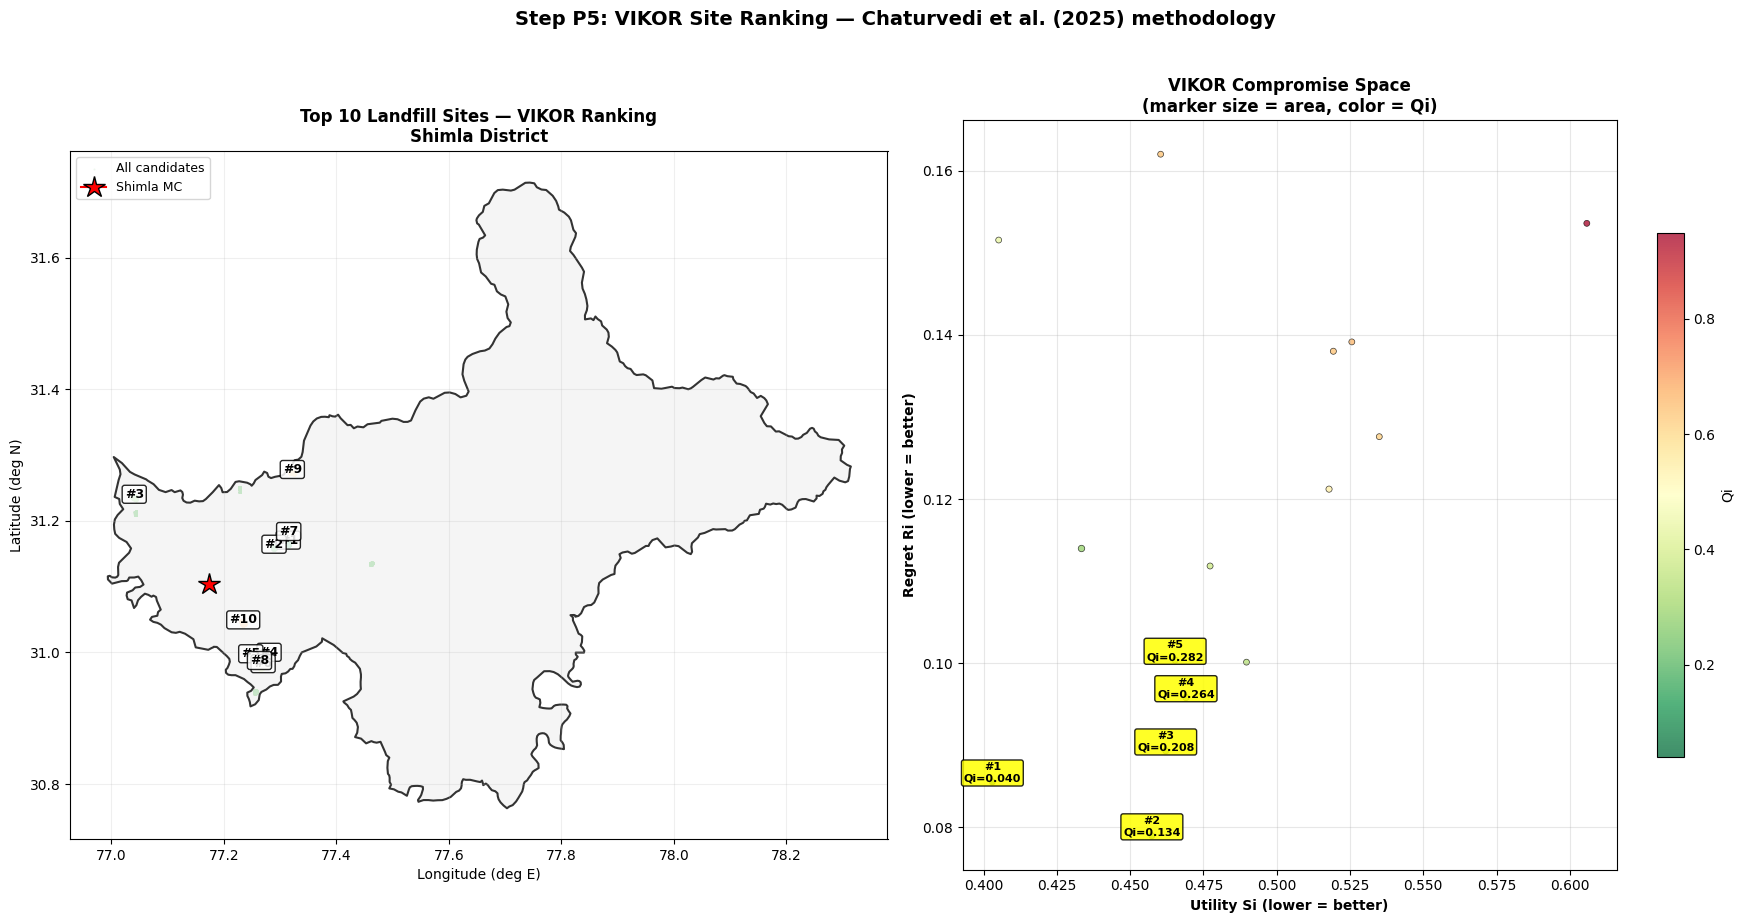

Saved: D:\\Important\Semester\Semester X\MTP\Shimla Result Paper based\P5_VIKOR_ranking.png


In [8]:
# ==============================================================
# CELL 3 — DETAILED PROFILE + VISUALIZATION OF TOP-RANKED SITES
# --------------------------------------------------------------
# Inputs:  P5_VIKOR_ranked_sites.csv, df_constrained, shimla, raster_transform
# Output:  P5_VIKOR_ranking.png + console profile of top 5
# ==============================================================
print("\n" + "=" * 60)
print("STEP P5 — CELL 3: TOP SITES PROFILE & VISUALIZATION")
print("=" * 60)
 
ranked_path = os.path.join(result_folder, "P5_VIKOR_ranked_sites.csv")
sites = pd.read_csv(ranked_path)
 
TOP_N_PROFILE = 5
TOP_N_MAP     = 10
 
# ---- DETAILED PROFILE ----
print(f"\nDetailed profile — top {TOP_N_PROFILE} sites:")
for _, row in sites.head(TOP_N_PROFILE).iterrows():
    print(f"\n  --- VIKOR RANK #{int(row['vikor_rank'])}  (Qi = {row['Qi']:.4f}) ---")
    print(f"  Cluster ID:       {int(row['cluster_id'])}")
    print(f"  Location:         {row['centroid_lat']:.4f}N, {row['centroid_lon']:.4f}E")
    print(f"  Area:             {row['area_ha']:.2f} ha ({row['area_sqkm']:.4f} sq.km)")
    print(f"  LSI (zoning):     {row['mean_lsi']:.4f}")
    print(f"  Beneficial criteria (higher = better):")
    print(f"    LSP landslide:    {row['mean_landslide_dist']:.0f} m")
    print(f"    LULC suit (1-5):  {row['mean_lulc']:.2f}")
    print(f"    WBP water:        {row['mean_water_dist']:.0f} m")
    print(f"    BUP built-up:     {row['mean_builtup_dist']:.0f} m")
    print(f"    LNP lineament:    {row['mean_lineament_dist']:.0f} m")
    print(f"    RAIL:             {row['mean_rail_dist']:.0f} m")
    print(f"  Non-beneficial criteria (lower = better):")
    print(f"    GSL slope:        {row['mean_slope']:.2f} deg")
    print(f"    GEL elevation:    {row['mean_elevation']:.0f} m")
    print(f"    ROAD:             {row['mean_road_dist']:.0f} m")
    print(f"    LNV land value:   Rs. {row['mean_land_value']:.0f}/sq.ft")
    print(f"    LST:              {row['mean_lst']:.2f} C")
    print(f"  VIKOR components: Si = {row['Si']:.4f}   Ri = {row['Ri']:.4f}")
    print(f"  Operational:      compactness = {row['compactness']:.3f}")
 
# ---- VISUALIZATION ----
print(f"\nGenerating VIKOR ranking visualization...")
shimla_latlon = shimla.to_crs("EPSG:4326")
transformer_to_latlon = Transformer.from_crs("EPSG:32643", "EPSG:4326", always_xy=True)
 
fig, axes = plt.subplots(1, 2, figsize=(18, 9))
 
# LEFT: top-N sites on the Shimla district map
ax1 = axes[0]
shimla_latlon.plot(ax=ax1, facecolor="#F5F5F5", edgecolor="#333333", linewidth=1.5)
 
# All surviving candidate pixels in light green for context
fdata = df_constrained[df_constrained["cluster_final"]]
fx = raster_transform.c + (fdata["pixel_col"].values * raster_transform.a)
fy = raster_transform.f + (fdata["pixel_row"].values * raster_transform.e)
flon, flat = transformer_to_latlon.transform(fx, fy)
 
np.random.seed(42)
if len(flon) > 200_000:
    idx = np.random.choice(len(flon), size=200_000, replace=False)
    ax1.scatter(flon[idx], flat[idx], c="#C8E6C9", s=0.3, alpha=0.25, label="All candidates")
else:
    ax1.scatter(flon, flat, c="#C8E6C9", s=0.3, alpha=0.25, label="All candidates")
 
# Top-N clusters with rank annotations (green = best, red = worst of top-N)
colors_top = plt.cm.RdYlGn(np.linspace(0.9, 0.3, TOP_N_MAP))
for i, (_, row) in enumerate(sites.head(TOP_N_MAP).iterrows()):
    cd = df_constrained[df_constrained["cluster_id_new"] == row["cluster_id"]]
    cx = raster_transform.c + (cd["pixel_col"].values * raster_transform.a)
    cy = raster_transform.f + (cd["pixel_row"].values * raster_transform.e)
    clon, clat = transformer_to_latlon.transform(cx, cy)
    if len(clon) > 20_000:
        sub = np.random.choice(len(clon), size=20_000, replace=False)
        clon, clat = clon[sub], clat[sub]
    ax1.scatter(clon, clat, c=[colors_top[i]], s=2, alpha=0.65)
    ax1.annotate(f"#{int(row['vikor_rank'])}",
                 (row["centroid_lon"], row["centroid_lat"]),
                 fontsize=9, fontweight="bold", color="black",
                 bbox=dict(boxstyle="round,pad=0.2", facecolor="white", alpha=0.85),
                 ha="center")
 
ax1.plot(77.1734, 31.1048, marker="*", color="red", markersize=16,
         markeredgecolor="black", markeredgewidth=1, label="Shimla MC", zorder=10)
ax1.set_title(f"Top {TOP_N_MAP} Landfill Sites — VIKOR Ranking\nShimla District",
              fontsize=12, fontweight="bold")
ax1.set_xlabel("Longitude (deg E)")
ax1.set_ylabel("Latitude (deg N)")
ax1.legend(loc="upper left", fontsize=9)
ax1.grid(True, alpha=0.2)
 
# RIGHT: Si–Ri compromise space (paper Fig. 5 analogue)
ax2 = axes[1]
sc = ax2.scatter(sites["Si"], sites["Ri"], c=sites["Qi"], cmap="RdYlGn_r",
                 s=sites["area_ha"].clip(upper=200) * 0.3 + 15,
                 alpha=0.75, edgecolors="black", linewidth=0.5)
 
for _, row in sites.head(TOP_N_PROFILE).iterrows():
    ax2.annotate(f"#{int(row['vikor_rank'])}\nQi={row['Qi']:.3f}",
                 (row["Si"], row["Ri"]), fontsize=8, fontweight="bold",
                 bbox=dict(boxstyle="round,pad=0.2", facecolor="yellow", alpha=0.85),
                 ha="center")
 
ax2.set_xlabel("Utility Si (lower = better)", fontweight="bold")
ax2.set_ylabel("Regret Ri (lower = better)", fontweight="bold")
ax2.set_title("VIKOR Compromise Space\n(marker size = area, color = Qi)",
              fontsize=12, fontweight="bold")
ax2.grid(True, alpha=0.3)
plt.colorbar(sc, ax=ax2, shrink=0.7, label="Qi")
 
plt.suptitle("Step P5: VIKOR Site Ranking — Chaturvedi et al. (2025) methodology",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
 
out_png = os.path.join(result_folder, "P5_VIKOR_ranking.png")
plt.savefig(out_png, dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved: {out_png}")

In [9]:
# ==============================================================
# CELL 1 — PHASE D: ANALYSIS B (30km radius, 15 sites)
# Same SHAP weights, same comparison logic as Analysis A.
# Load from the Analysis B result folder.
# ==============================================================
print("=" * 60)
print("PHASE D — ANALYSIS B (30km from Shimla MC)")
print("=" * 60)
 
# ---- paths for Analysis B ----
# result_folder_B = os.path.join(result_folder, "B_within30km_of_ShimlaMC")
 
stats_path_B  = os.path.join(result_folder, "P5_candidate_sites_stats.csv")
mcda_path_B   = os.path.join(result_folder, "P5_VIKOR_ranked_sites.csv")
 
sites_ml_B = pd.read_csv(stats_path_B)
sites_ahp_B = pd.read_csv(mcda_path_B)
print(f"Analysis B: {len(sites_ml_B)} candidate sites")
 
# ---- same 11 criteria (unchanged) ----
criteria_meta = {
    "mean_landslide_dist": {"code": "LSP",  "type": "beneficial"},
    "mean_lulc":           {"code": "LULC", "type": "beneficial"},
    "mean_water_dist":     {"code": "WBP",  "type": "beneficial"},
    "mean_builtup_dist":   {"code": "BUP",  "type": "beneficial"},
    "mean_lineament_dist": {"code": "LNP",  "type": "beneficial"},
    "mean_rail_dist":      {"code": "RAIL", "type": "beneficial"},
    "mean_slope":          {"code": "GSL",  "type": "non-beneficial"},
    "mean_elevation":      {"code": "GEL",  "type": "non-beneficial"},
    "mean_road_dist":      {"code": "ROAD", "type": "non-beneficial"},
    "mean_land_value":     {"code": "LNV",  "type": "non-beneficial"},
    "mean_lst":            {"code": "LST",  "type": "non-beneficial"},
}
criteria_cols = list(criteria_meta.keys())
 
# ---- SHAP weights (same as Analysis A — global district weights) ----
shap_weights_raw = {
    "mean_road_dist":      0.1528,  # ROAD — SHAP rank #1 (AHP rank #5)
    "mean_elevation":      0.1465,  # GEL  — SHAP rank #2 (AHP rank #4)
    "mean_builtup_dist":   0.1436,  # BUP  — SHAP rank #3 (AHP rank #6)
    "mean_slope":          0.1326,  # GSL  — SHAP rank #4 (AHP rank #2)
    "mean_landslide_dist": 0.1165,  # LSP  — SHAP rank #5 (AHP rank #1)
    "mean_land_value":     0.1165,  # LNV  — SHAP rank #6 (AHP rank #7)
    "mean_lineament_dist": 0.1015,  # LNP  — SHAP rank #7 (AHP rank #9)
    "mean_lst":            0.0523,  # LST  — SHAP rank #8 (AHP rank #10)
    "mean_water_dist":     0.0180,  # WBP  — SHAP rank #9 (AHP rank #8)
    "mean_lulc":           0.0126,  # LULC — SHAP rank #10 (AHP rank #3)
    "mean_rail_dist":      0.0071,  # RAIL — SHAP rank #11 (AHP rank #11)
}

shap_weights = np.array([shap_weights_raw[c] for c in criteria_cols])
 
ahp_weights_raw = {
    "mean_landslide_dist": 0.162,
    "mean_slope":          0.138,
    "mean_lulc":           0.122,
    "mean_elevation":      0.114,
    "mean_road_dist":      0.095,
    "mean_builtup_dist":   0.084,
    "mean_land_value":     0.079,
    "mean_water_dist":     0.061,
    "mean_lineament_dist": 0.056,
    "mean_lst":            0.048,
    "mean_rail_dist":      0.041,
}
ahp_weights = np.array([ahp_weights_raw[c] for c in criteria_cols])
 
# ---- VIKOR with SHAP weights on Analysis B pool ----
X_B = sites_ml_B[criteria_cols].values.astype(np.float64)
n_B = len(sites_ml_B)
 
R_B = np.zeros_like(X_B)
for j, col in enumerate(criteria_cols):
    x = X_B[:, j]
    xmin, xmax = x.min(), x.max()
    if xmax == xmin:
        R_B[:, j] = 0.0
    elif criteria_meta[col]["type"] == "beneficial":
        R_B[:, j] = (xmax - x) / (xmax - xmin)
    else:
        R_B[:, j] = (x - xmin) / (xmax - xmin)
 
V_B = R_B * shap_weights
S_B = V_B.sum(axis=1)
Rg_B = V_B.max(axis=1)
 
v = 0.5
S_star_B, S_minus_B = S_B.min(), S_B.max()
R_star_B, R_minus_B = Rg_B.min(), Rg_B.max()
Q_S_B = np.zeros(n_B) if S_minus_B == S_star_B else \
        v * (S_B - S_star_B) / (S_minus_B - S_star_B)
Q_R_B = np.zeros(n_B) if R_minus_B == R_star_B else \
        (1-v) * (Rg_B - R_star_B) / (R_minus_B - R_star_B)
Q_B = Q_S_B + Q_R_B
 
sites_ml_B["Si_shap"] = S_B
sites_ml_B["Ri_shap"] = Rg_B
sites_ml_B["Qi_shap"] = Q_B
sites_ml_B["ml_rank"] = sites_ml_B["Qi_shap"].rank(method="min").astype(int)
sites_ml_B = sites_ml_B.sort_values("ml_rank").reset_index(drop=True)
 
ml_B_path = os.path.join(result_folder, "B_ML_VIKOR_ranked_sites.csv")
sites_ml_B.to_csv(ml_B_path, index=False)
 
# ---- merge AHP + SHAP ----
comp_B = sites_ml_B[["cluster_id", "ml_rank", "Qi_shap",
                       "mean_landslide_dist", "mean_elevation",
                       "mean_road_dist", "centroid_lat", "centroid_lon",
                       "area_ha"]].copy()
comp_B = comp_B.merge(
    sites_ahp_B[["cluster_id", "vikor_rank", "Qi"]],
    on="cluster_id", how="inner"
)
comp_B = comp_B.rename(columns={"vikor_rank": "ahp_rank", "Qi": "Qi_ahp"})
comp_B["rank_change"] = comp_B["ahp_rank"] - comp_B["ml_rank"]
 
print(f"Merged {len(comp_B)} clusters")
 
# ---- Spearman ----
from scipy.stats import spearmanr, mannwhitneyu
spearman_B, p_spearman_B = spearmanr(comp_B["ahp_rank"], comp_B["ml_rank"])
print(f"\nSpearman rank correlation (Analysis B): ρ = {spearman_B:.4f} (p = {p_spearman_B:.4f})")
if spearman_B > 0.8:
    print("  → Strong agreement: ML validates AHP within 30km of Shimla MC")
elif spearman_B > 0.5:
    print("  → Moderate agreement: some reordering within the MC-proximate pool")
else:
    print("  → Weak agreement: weights change recommendations even at MC scale")
 
# ---- Top-N overlap (use min(10, n) since only 15 sites) ----
top_n_B = min(10, len(comp_B))
top_ahp_B_ids = set(comp_B.nsmallest(top_n_B, "ahp_rank")["cluster_id"])
top_ml_B_ids  = set(comp_B.nsmallest(top_n_B, "ml_rank")["cluster_id"])
overlap_B = len(top_ahp_B_ids & top_ml_B_ids)
print(f"\nTop-{top_n_B} overlap: {overlap_B}/{top_n_B} sites in both AHP and SHAP top-{top_n_B}")
print(f"  AHP only: {top_ahp_B_ids - top_ml_B_ids}")
print(f"  SHAP only: {top_ml_B_ids - top_ahp_B_ids}")
 
# ---- Landslide distance test ----
top_ahp_B_lsp = comp_B.nsmallest(top_n_B, "ahp_rank")["mean_landslide_dist"].values
top_ml_B_lsp  = comp_B.nsmallest(top_n_B, "ml_rank")["mean_landslide_dist"].values
if len(top_ahp_B_lsp) >= 3 and len(top_ml_B_lsp) >= 3:
    stat_B, p_B = mannwhitneyu(top_ml_B_lsp, top_ahp_B_lsp, alternative="two-sided")
    print(f"\nLandslide Distance Test (Analysis B, top {top_n_B}, Mann-Whitney U):")
    print(f"  AHP top-{top_n_B} mean LSP dist:  {top_ahp_B_lsp.mean():.0f} m")
    print(f"  SHAP top-{top_n_B} mean LSP dist: {top_ml_B_lsp.mean():.0f} m")
    print(f"  U = {stat_B:.1f}, p = {p_B:.4f}")
    if p_B < 0.05:
        direction = "lower" if top_ml_B_lsp.mean() < top_ahp_B_lsp.mean() else "higher"
        print(f"  → Significant: SHAP top sites have {direction} landslide distance (p < 0.05)")
    else:
        print(f"  → Not significant at p < 0.05 (small sample — only {top_n_B} sites)")
else:
    print(f"\n  Mann-Whitney skipped — too few sites for reliable test ({top_n_B})")
 
# ---- Side-by-side top-N ----
print(f"\n{'=' * 60}")
print(f"TOP {top_n_B} SIDE BY SIDE — ANALYSIS B")
print("=" * 60)
ahp_topN_B = comp_B.nsmallest(top_n_B, "ahp_rank").reset_index(drop=True)
ml_topN_B  = comp_B.nsmallest(top_n_B, "ml_rank").reset_index(drop=True)
 
print(f"\n  AHP (MCDA):                           SHAP (ML):")
print(f"  {'Rk':>3} {'Clust':>7} {'Qi':>6} {'LSP':>6} {'Elev':>5}    "
      f"{'Rk':>3} {'Clust':>7} {'Qi':>6} {'LSP':>6} {'Elev':>5}")
print("  " + "-" * 72)
for i in range(top_n_B):
    ar = ahp_topN_B.iloc[i]
    mr = ml_topN_B.iloc[i]
    match = "✓" if ar["cluster_id"] == mr["cluster_id"] else " "
    print(f"  {int(ar['ahp_rank']):>3} {int(ar['cluster_id']):>7} "
          f"{ar['Qi_ahp']:>6.3f} {ar['mean_landslide_dist']:>6.0f} "
          f"{ar['mean_elevation']:>5.0f} {match}  "
          f"{int(mr['ml_rank']):>3} {int(mr['cluster_id']):>7} "
          f"{mr['Qi_shap']:>6.3f} {mr['mean_landslide_dist']:>6.0f} "
          f"{mr['mean_elevation']:>5.0f}")
 
# ---- Rank change summary ----
print(f"\nLargest rank changes (Analysis B):")
print(f"  {'Cluster':>8} {'AHP':>6} {'SHAP':>6} {'Change':>8} {'LSP':>8} {'Elev':>7}")
print("  " + "-" * 50)
for _, row in comp_B.reindex(
    comp_B["rank_change"].abs().sort_values(ascending=False).index
).head(5).iterrows():
    d = "↑" if row["rank_change"] > 0 else "↓"
    print(f"  {int(row['cluster_id']):>8} {int(row['ahp_rank']):>6} "
          f"{int(row['ml_rank']):>6} {d}{abs(row['rank_change']):>6.0f} "
          f"{row['mean_landslide_dist']:>8.0f} {row['mean_elevation']:>7.0f}")
 
print(f"\n✓ Saved: {ml_B_path}")

PHASE D — ANALYSIS B (30km from Shimla MC)
Analysis B: 15 candidate sites
Merged 15 clusters

Spearman rank correlation (Analysis B): ρ = 0.4071 (p = 0.1320)
  → Weak agreement: weights change recommendations even at MC scale

Top-10 overlap: 8/10 sites in both AHP and SHAP top-10
  AHP only: {580, 991}
  SHAP only: {416, 180}

Landslide Distance Test (Analysis B, top 10, Mann-Whitney U):
  AHP top-10 mean LSP dist:  3717 m
  SHAP top-10 mean LSP dist: 3306 m
  U = 43.0, p = 0.6221
  → Not significant at p < 0.05 (small sample — only 10 sites)

TOP 10 SIDE BY SIDE — ANALYSIS B

  AHP (MCDA):                           SHAP (ML):
   Rk   Clust     Qi    LSP  Elev     Rk   Clust     Qi    LSP  Elev
  ------------------------------------------------------------------------
    1     668  0.040   4763  1802      1      72  0.120   1193   850
    2     688  0.134   5304  1652      2    1472  0.145   3012  1500
    3     292  0.208   3405  1215      3    1659  0.195   4257  1441
    4    1448

ANALYSIS B — SITE VISUALIZATION


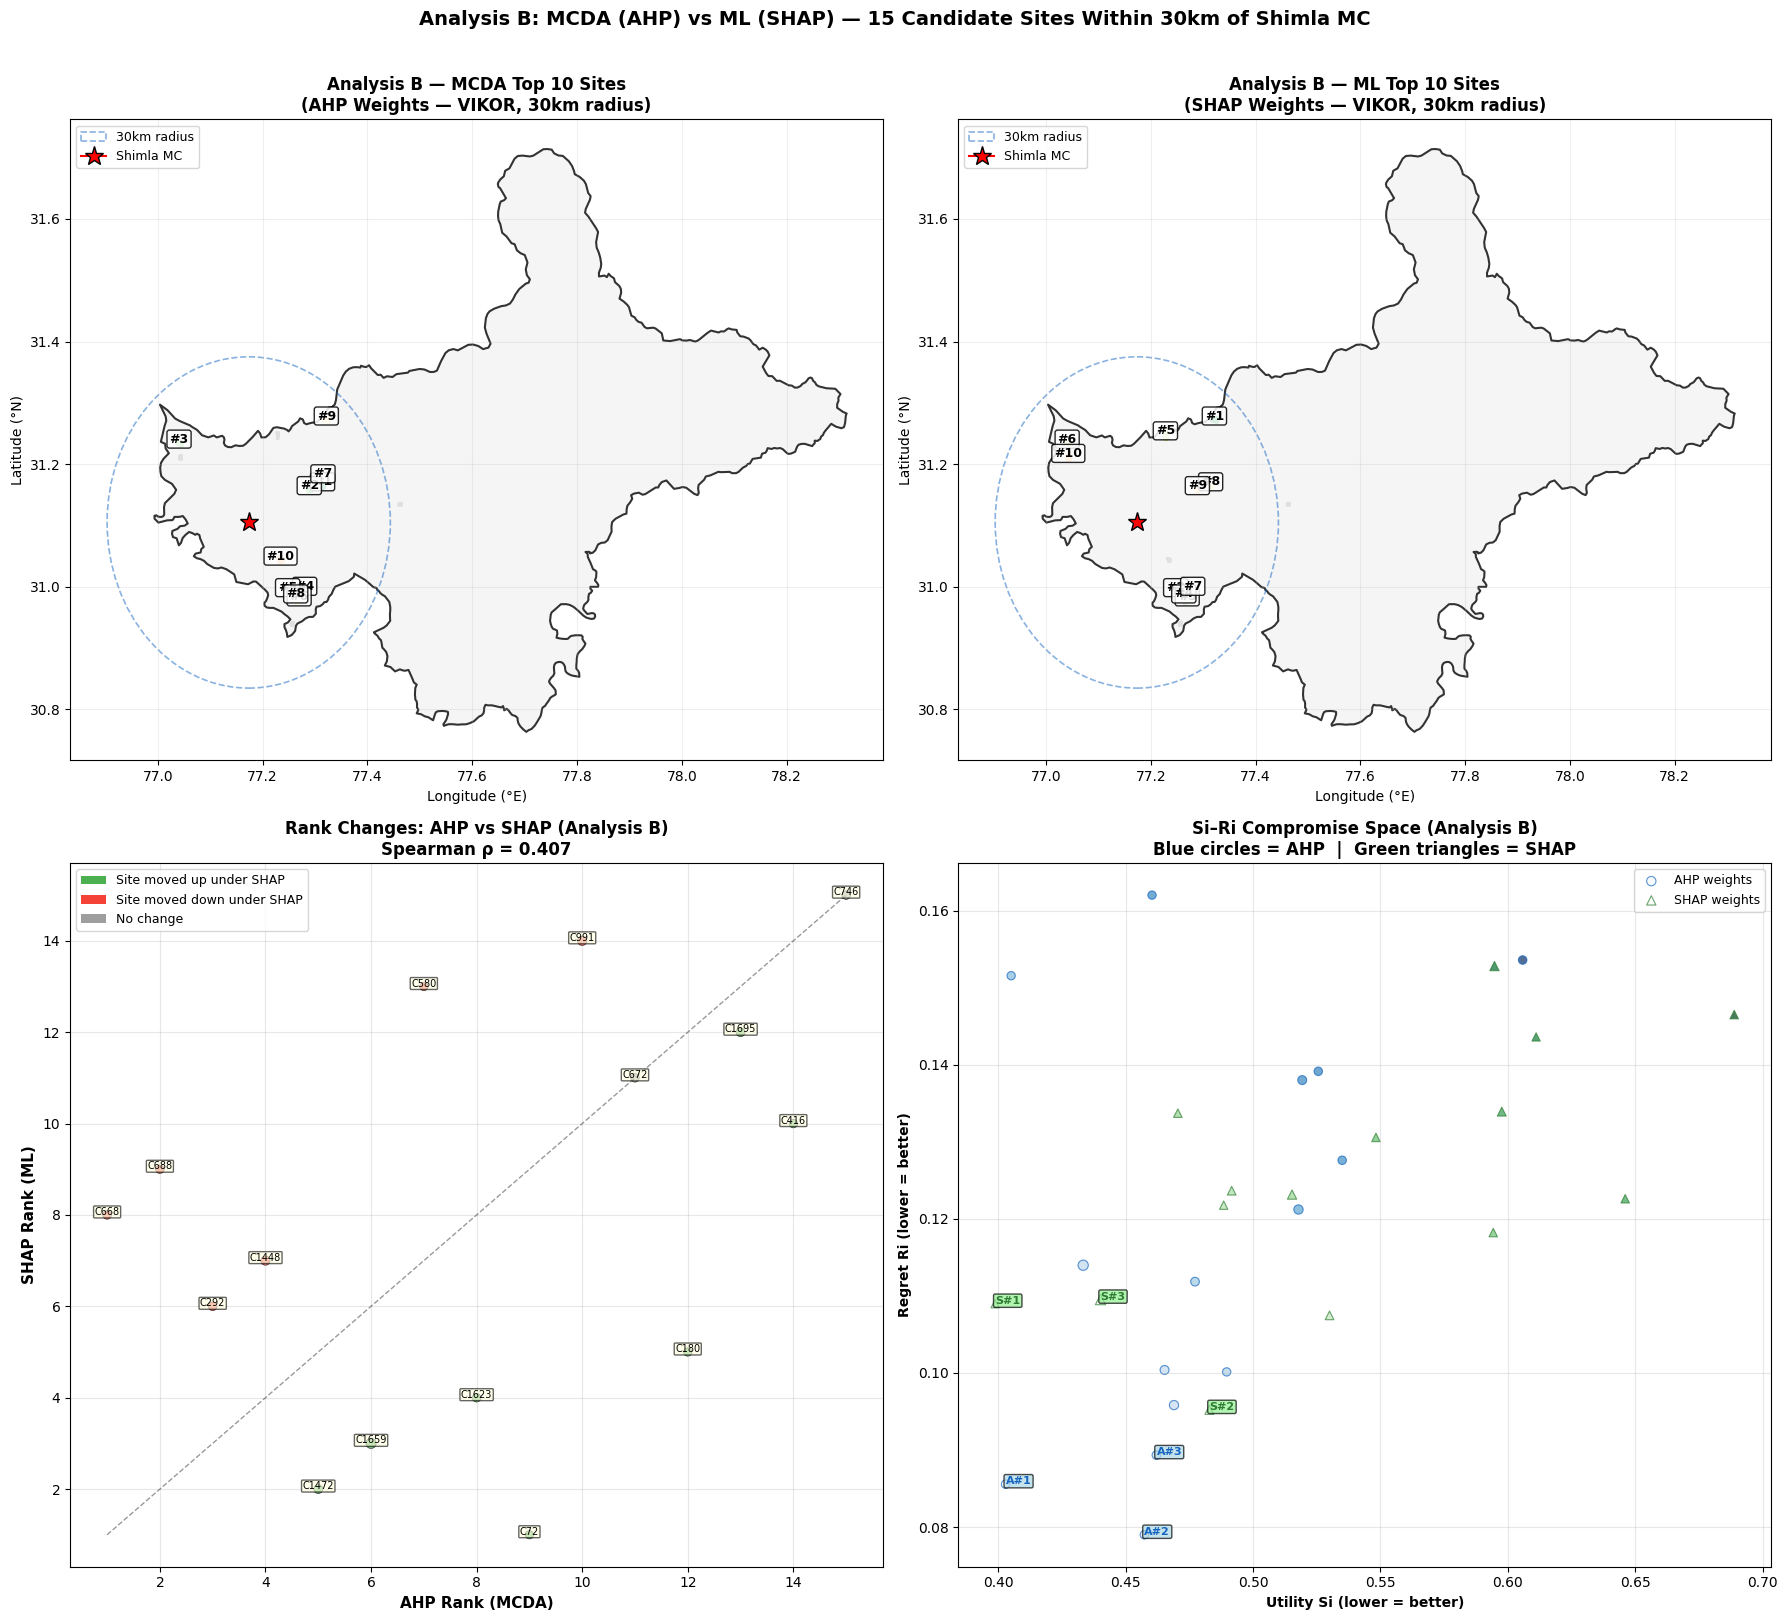

✓ Saved: D:\\Important\Semester\Semester X\MTP\Shimla Result Paper based\D_AnalysisB_AHP_vs_SHAP_comparison.png


In [11]:
# ==============================================================
# CELL 1B — VISUALIZATION: ANALYSIS B TOP SITES
# AHP top-N and SHAP top-N mapped side by side
# Plus Si-Ri compromise space for both weight schemes
# ==============================================================
print("=" * 60)
print("ANALYSIS B — SITE VISUALIZATION")
print("=" * 60)

shimla_latlon = shimla.to_crs("EPSG:4326")
transformer_to_latlon = Transformer.from_crs("EPSG:32643", "EPSG:4326", always_xy=True)

# All Analysis B candidate pixels (for background scatter)
f_data_B = df_constrained[df_constrained["cluster_final"]]
f_x_B = raster_transform.c + (f_data_B["pixel_col"].values * raster_transform.a)
f_y_B = raster_transform.f + (f_data_B["pixel_row"].values * raster_transform.e)
f_lon_B, f_lat_B = transformer_to_latlon.transform(f_x_B, f_y_B)

top_n_B = min(10, len(comp_B))
ahp_topN_B = comp_B.nsmallest(top_n_B, "ahp_rank").reset_index(drop=True)
ml_topN_B  = comp_B.nsmallest(top_n_B, "ml_rank").reset_index(drop=True)
colors_top = plt.cm.RdYlGn(np.linspace(0.9, 0.3, top_n_B))

fig, axes = plt.subplots(2, 2, figsize=(18, 16))

# ---- helper: plot one top-N set on a given axis ----
def plot_top_sites(ax, top_df, rank_col, title, label_col="ahp_rank"):
    shimla_latlon.plot(ax=ax, facecolor="#F5F5F5", edgecolor="#333333", linewidth=1.5)

    # Background: all Analysis B candidates
    np.random.seed(42)
    if len(f_lon_B) > 100_000:
        idx = np.random.choice(len(f_lon_B), 100_000, replace=False)
        ax.scatter(f_lon_B[idx], f_lat_B[idx], c="#E0E0E0", s=0.4, alpha=0.3)
    else:
        ax.scatter(f_lon_B, f_lat_B, c="#E0E0E0", s=0.4, alpha=0.3)

    # 30km radius circle around Shimla MC (dashed) for reference
    import matplotlib.patches as mpatches
    circle = plt.Circle((77.1734, 31.1048),
                         30 / 111.0,          # 30km in degrees (approx)
                         color="#1565C0", fill=False,
                         linestyle="--", linewidth=1.2, alpha=0.5,
                         label="30km radius")
    ax.add_patch(circle)

    # Top-N clusters
    for i, (_, row) in enumerate(top_df.iterrows()):
        cid = row["cluster_id"]
        cd = df_constrained[df_constrained["cluster_id_new"] == cid]
        cx = raster_transform.c + (cd["pixel_col"].values * raster_transform.a)
        cy = raster_transform.f + (cd["pixel_row"].values * raster_transform.e)
        clon, clat = transformer_to_latlon.transform(cx, cy)
        if len(clon) > 10_000:
            sub = np.random.choice(len(clon), 10_000, replace=False)
            clon, clat = clon[sub], clat[sub]
        ax.scatter(clon, clat, c=[colors_top[i]], s=4, alpha=0.8)
        ax.annotate(
            f"#{int(row[rank_col])}",
            (row["centroid_lon"], row["centroid_lat"]),
            fontsize=9, fontweight="bold", color="black",
            bbox=dict(boxstyle="round,pad=0.2", facecolor="white", alpha=0.85),
            ha="center"
        )

    # Shimla MC star
    ax.plot(77.1734, 31.1048, marker="*", color="red", markersize=14,
            markeredgecolor="black", markeredgewidth=1,
            label="Shimla MC", zorder=10)

    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.set_xlabel("Longitude (°E)")
    ax.set_ylabel("Latitude (°N)")
    ax.legend(fontsize=9, loc="upper left")
    ax.grid(True, alpha=0.2)

# ---- Top-left: AHP top-N ----
plot_top_sites(
    axes[0, 0], ahp_topN_B, "ahp_rank",
    f"Analysis B — MCDA Top {top_n_B} Sites\n(AHP Weights — VIKOR, 30km radius)"
)

# ---- Top-right: SHAP top-N ----
plot_top_sites(
    axes[0, 1], ml_topN_B, "ml_rank",
    f"Analysis B — ML Top {top_n_B} Sites\n(SHAP Weights — VIKOR, 30km radius)"
)

# ---- Bottom-left: Rank change scatter ----
ax3 = axes[1, 0]
colors_change = ["#4CAF50" if x > 0 else ("#F44336" if x < 0 else "#9E9E9E")
                 for x in comp_B["rank_change"]]
ax3.scatter(comp_B["ahp_rank"], comp_B["ml_rank"],
            c=colors_change,
            s=comp_B["area_ha"].clip(upper=100) * 1.5 + 20,
            alpha=0.75, edgecolors="black", linewidth=0.5)

max_rank_B = max(comp_B["ahp_rank"].max(), comp_B["ml_rank"].max())
ax3.plot([1, max_rank_B], [1, max_rank_B], "k--", alpha=0.4, linewidth=1)

# Annotate all sites (only 15 — readable)
for _, row in comp_B.iterrows():
    ax3.annotate(
        f"C{int(row['cluster_id'])}",
        (row["ahp_rank"], row["ml_rank"]),
        fontsize=7, ha="center",
        bbox=dict(boxstyle="round,pad=0.1", facecolor="lightyellow", alpha=0.6)
    )

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="#4CAF50", label="Site moved up under SHAP"),
    Patch(facecolor="#F44336", label="Site moved down under SHAP"),
    Patch(facecolor="#9E9E9E", label="No change"),
]
ax3.legend(handles=legend_elements, fontsize=9)
ax3.set_xlabel("AHP Rank (MCDA)", fontsize=11, fontweight="bold")
ax3.set_ylabel("SHAP Rank (ML)", fontsize=11, fontweight="bold")
ax3.set_title(f"Rank Changes: AHP vs SHAP (Analysis B)\nSpearman ρ = {spearman_B:.3f}",
              fontsize=12, fontweight="bold")
ax3.grid(True, alpha=0.3)

# ---- Bottom-right: Si-Ri compromise space (both weight schemes) ----
ax4 = axes[1, 1]

# AHP compromise space from Analysis B AHP-ranked file
sc_ahp = ax4.scatter(
    sites_ahp_B["Si"], sites_ahp_B["Ri"],
    c=sites_ahp_B["Qi"], cmap="Blues",
    s=sites_ahp_B["area_ha"].clip(upper=100) * 1.5 + 20,
    alpha=0.7, edgecolors="#1565C0", linewidth=0.8,
    label="AHP weights", marker="o"
)
# SHAP compromise space
sc_shap = ax4.scatter(
    sites_ml_B["Si_shap"], sites_ml_B["Ri_shap"],
    c=sites_ml_B["Qi_shap"], cmap="Greens",
    s=sites_ml_B["area_ha"].clip(upper=100) * 1.5 + 20,
    alpha=0.7, edgecolors="#2E7D32", linewidth=0.8,
    label="SHAP weights", marker="^"
)

# Annotate top 3 from each
for _, row in sites_ahp_B.nsmallest(3, "vikor_rank").iterrows():
    ax4.annotate(f"A#{int(row['vikor_rank'])}",
                 (row["Si"], row["Ri"]),
                 fontsize=8, color="#1565C0", fontweight="bold",
                 bbox=dict(boxstyle="round,pad=0.15", facecolor="lightblue", alpha=0.7))
for _, row in sites_ml_B.nsmallest(3, "ml_rank").iterrows():
    ax4.annotate(f"S#{int(row['ml_rank'])}",
                 (row["Si_shap"], row["Ri_shap"]),
                 fontsize=8, color="#2E7D32", fontweight="bold",
                 bbox=dict(boxstyle="round,pad=0.15", facecolor="lightgreen", alpha=0.7))

ax4.set_xlabel("Utility Si (lower = better)", fontweight="bold")
ax4.set_ylabel("Regret Ri (lower = better)", fontweight="bold")
ax4.set_title("Si–Ri Compromise Space (Analysis B)\nBlue circles = AHP  |  Green triangles = SHAP",
              fontsize=12, fontweight="bold")
ax4.legend(fontsize=9)
ax4.grid(True, alpha=0.3)

plt.suptitle(
    f"Analysis B: MCDA (AHP) vs ML (SHAP) — {len(comp_B)} Candidate Sites Within 30km of Shimla MC",
    fontsize=14, fontweight="bold", y=1.01
)
plt.tight_layout()

out_B = os.path.join(result_folder, "D_AnalysisB_AHP_vs_SHAP_comparison.png")
plt.savefig(out_B, dpi=300, bbox_inches="tight")
plt.show()
print(f"✓ Saved: {out_B}")

In [10]:
# ==============================================================
# CELL 2 — GOOGLE MAPS LINKS: ALL TOP SITES
# Analysis A (54 sites) + Analysis B (15 sites)
# AHP ranking + SHAP ranking for each
# ==============================================================
print("\n" + "=" * 60)
print("GOOGLE MAPS LINKS — TOP SITES")
print("All links open satellite view at ~500m zoom")
print("=" * 60)
 
def maps_link(lat, lon):
    return (f"https://www.google.com/maps/@{lat:.5f},{lon:.5f},"
            f"500m/data=!3m1!1e3")
 
def print_top_sites(label, df_ranked, rank_col, qi_col, n=10):
    print(f"\n{'─' * 60}")
    print(f"{label}")
    print(f"{'─' * 60}")
    print(f"  {'Rk':>3}  {'Cluster':>8}  {'Qi':>6}  {'LSP':>6}  {'Elev':>5}  "
          f"{'Slope':>6}  {'Road':>5}  {'Lat':>9}  {'Lon':>9}")
    print(f"  {'':─<3}  {'':─<8}  {'':─<6}  {'':─<6}  {'':─<5}  "
          f"{'':─<6}  {'':─<5}  {'':─<9}  {'':─<9}")
    top = df_ranked.nsmallest(n, rank_col).reset_index(drop=True)
    for _, row in top.iterrows():
        print(f"  {int(row[rank_col]):>3}  {int(row['cluster_id']):>8}  "
              f"{row[qi_col]:>6.3f}  "
              f"{row['mean_landslide_dist']:>6.0f}  "
              f"{row['mean_elevation']:>5.0f}  "
              f"{row['mean_slope']:>6.1f}  "
              f"{row['mean_road_dist']:>5.0f}  "
              f"{row['centroid_lat']:>9.5f}  "
              f"{row['centroid_lon']:>9.5f}")
        print(f"       → {maps_link(row['centroid_lat'], row['centroid_lon'])}")
 
# ---- ANALYSIS A — AHP top 10 ----
# Load AHP-ranked file for Analysis A
sites_ahp_A = pd.read_csv(os.path.join(result_folder, "P5_VIKOR_ranked_sites.csv"))
print_top_sites(
    "ANALYSIS A — MCDA (AHP Weights) — Top 10 — District-wide (54 sites)",
    sites_ahp_A, "vikor_rank", "Qi"
)
 
# ---- ANALYSIS A — SHAP top 10 ----
sites_ml_A = pd.read_csv(os.path.join(result_folder, "B_ML_VIKOR_ranked_sites.csv"))
print_top_sites(
    "ANALYSIS A — ML (SHAP Weights) — Top 10 — District-wide (54 sites)",
    sites_ml_A, "ml_rank", "Qi_shap"
)
 
# ---- ANALYSIS B — AHP top 10 ----
print_top_sites(
    "ANALYSIS B — MCDA (AHP Weights) — Top 10 — Within 30km of Shimla MC (15 sites)",
    sites_ahp_B, "vikor_rank", "Qi"
)
 
# ---- ANALYSIS B — SHAP top 10 ----
print_top_sites(
    "ANALYSIS B — ML (SHAP Weights) — Top 10 — Within 30km of Shimla MC (15 sites)",
    sites_ml_B, "ml_rank", "Qi_shap"
)
 
# ---- Primary recommendation: site that appears #1 in BOTH methods ----
print(f"\n{'=' * 60}")
print("PRIMARY RECOMMENDATION — ROBUST ACROSS BOTH WEIGHT SCHEMES")
print("=" * 60)
 
# Find clusters that are top-5 in both AHP and SHAP (Analysis A)
ahp_A_top5  = set(sites_ahp_A.nsmallest(5, "vikor_rank")["cluster_id"])
shap_A_top5 = set(sites_ml_A.nsmallest(5, "ml_rank")["cluster_id"])
robust_A = ahp_A_top5 & shap_A_top5
 
if robust_A:
    print(f"\nAnalysis A — clusters in BOTH AHP top-5 AND SHAP top-5: {robust_A}")
    for cid in robust_A:
        row = sites_ahp_A[sites_ahp_A["cluster_id"] == cid].iloc[0]
        ahp_r = int(row["vikor_rank"])
        shap_r = int(sites_ml_A[sites_ml_A["cluster_id"] == cid]["ml_rank"].values[0])
        print(f"\n  Cluster {int(cid)} — AHP rank #{ahp_r}, SHAP rank #{shap_r}")
        print(f"  Location:   {row['centroid_lat']:.5f}N, {row['centroid_lon']:.5f}E")
        print(f"  Area:       {row['area_ha']:.2f} ha")
        print(f"  Elevation:  {row['mean_elevation']:.0f} m")
        print(f"  Slope:      {row['mean_slope']:.1f} deg")
        print(f"  Road dist:  {row['mean_road_dist']:.0f} m")
        print(f"  LSP dist:   {row['mean_landslide_dist']:.0f} m")
        print(f"  Google Maps: {maps_link(row['centroid_lat'], row['centroid_lon'])}")
else:
    print("\nNo cluster appears in top-5 of both AHP and SHAP (Analysis A).")
    print("Showing top-3 each for reference:")
 
# Same for Analysis B
ahp_B_top5  = set(sites_ahp_B.nsmallest(5, "vikor_rank")["cluster_id"])
shap_B_top5 = set(sites_ml_B.nsmallest(5, "ml_rank")["cluster_id"])
robust_B = ahp_B_top5 & shap_B_top5
 
if robust_B:
    print(f"\nAnalysis B — clusters in BOTH AHP top-5 AND SHAP top-5: {robust_B}")
    for cid in robust_B:
        row = sites_ahp_B[sites_ahp_B["cluster_id"] == cid].iloc[0]
        ahp_r = int(row["vikor_rank"])
        shap_r = int(sites_ml_B[sites_ml_B["cluster_id"] == cid]["ml_rank"].values[0])
        print(f"\n  Cluster {int(cid)} — AHP rank #{ahp_r}, SHAP rank #{shap_r}")
        print(f"  Location:   {row['centroid_lat']:.5f}N, {row['centroid_lon']:.5f}E")
        print(f"  Area:       {row['area_ha']:.2f} ha")
        print(f"  Elevation:  {row['mean_elevation']:.0f} m")
        print(f"  Slope:      {row['mean_slope']:.1f} deg")
        print(f"  Road dist:  {row['mean_road_dist']:.0f} m")
        print(f"  LSP dist:   {row['mean_landslide_dist']:.0f} m")
        print(f"  Google Maps: {maps_link(row['centroid_lat'], row['centroid_lon'])}")
else:
    print("\nNo cluster appears in top-5 of both AHP and SHAP (Analysis B).")


GOOGLE MAPS LINKS — TOP SITES
All links open satellite view at ~500m zoom

────────────────────────────────────────────────────────────
ANALYSIS A — MCDA (AHP Weights) — Top 10 — District-wide (54 sites)
────────────────────────────────────────────────────────────
   Rk   Cluster      Qi     LSP   Elev   Slope   Road        Lat        Lon
  ───  ────────  ──────  ──────  ─────  ──────  ─────  ─────────  ─────────
    1       668   0.040    4763   1802    16.4     90   31.16543   77.31427
       → https://www.google.com/maps/@31.16543,77.31427,500m/data=!3m1!1e3
    2       688   0.134    5304   1652    16.6    452   31.15916   77.28899
       → https://www.google.com/maps/@31.15916,77.28899,500m/data=!3m1!1e3
    3       292   0.208    3405   1215    17.8    171   31.23510   77.04043
       → https://www.google.com/maps/@31.23510,77.04043,500m/data=!3m1!1e3
    4      1448   0.264    4057   1917    17.5    186   30.99491   77.28008
       → https://www.google.com/maps/@30.99491,77.280